# Modelamiento de Redes Cerebrales
## Fundamentos de Teoría de Redes aplicados a Neurociencia Computacional


**Tema:** Teoría y Modelamiento de Redes  

---

Este notebook desarrolla los conceptos fundamentales de teoría de redes utilizando el **cerebro humano** como sistema de aplicación. El cerebro es uno de los ejemplos más ricos de red compleja en la naturaleza: sus 86 mil millones de neuronas forman una red de interacciones cuya dinámica genera cognición, memoria y comportamiento.


- De poblaciones individuales → a redes de poblaciones acopladas
- Del crecimiento logístico → a dinámicas neuronales no lineales
- Del caos determinista → a estados patológicos cerebrales (epilepsia)

### Regiones cerebrales modeladas
| Nodo | Región | Función principal |
|------|--------|------------------|
| V1 | Corteza visual primaria | Procesamiento visual |
| PFC | Corteza prefrontal | Funciones ejecutivas |
| M1 | Corteza motora | Control motor |
| HC | Hipocampo | Memoria |
| AMY | Amígdala | Respuesta emocional |
| TH | Tálamo | Relevo sensorial |
| CB | Cerebelo | Coordinación motora |
| BS | Tronco encefálico | Funciones vitales |

In [1]:
# ============================================================
# IMPORTACIONES GLOBALES
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings('ignore')

# Estilo global de gráficas
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccff',
    'xtick.color':      '#ccccff',
    'ytick.color':      '#ccccff',
    'text.color':       '#ccccff',
    'grid.color':       '#333355',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'monospace',
})

# Nombres de regiones cerebrales
REGIONES = ['V1', 'PFC', 'M1', 'HC', 'AMY', 'TH', 'CB', 'BS']
NOMBRES  = ['Corteza Visual', 'Prefrontal', 'Corteza Motora',
            'Hipocampo', 'Amigdala', 'Talamo', 'Cerebelo', 'Tronco Encefalico']
N = len(REGIONES)

# Colores por region
COLORES = ['#ff6b6b','#4ecdc4','#45b7d1','#96ceb4',
           '#ffeaa7','#dda0dd','#98fb98','#f0e68c']

print('Librerias cargadas correctamente.')
print(f'Red cerebral: {N} regiones -> {REGIONES}')

Librerias cargadas correctamente.
Red cerebral: 8 regiones -> ['V1', 'PFC', 'M1', 'HC', 'AMY', 'TH', 'CB', 'BS']


---
## 1. Definición de Red

Una **red** (o grafo) es una estructura matemática $G = (V, E)$ donde:
- $V$ = conjunto de **vértices** (nodos): entidades del sistema
- $E$ = conjunto de **enlaces** (aristas): relaciones entre entidades

### Red cerebral como grafo
En el cerebro, la interpretación es directa:
- **Nodos** → regiones cerebrales (o neuronas individuales)
- **Enlace** → conexión sináptica o correlación funcional entre regiones

Esta representación, llamada **conectoma**, permite aplicar todas las herramientas de la teoría de redes al estudio de la cognición y las enfermedades neurológicas.

Formalmente, una red con $N$ nodos tiene como máximo $\binom{N}{2} = \frac{N(N-1)}{2}$ enlaces posibles (red no dirigida).

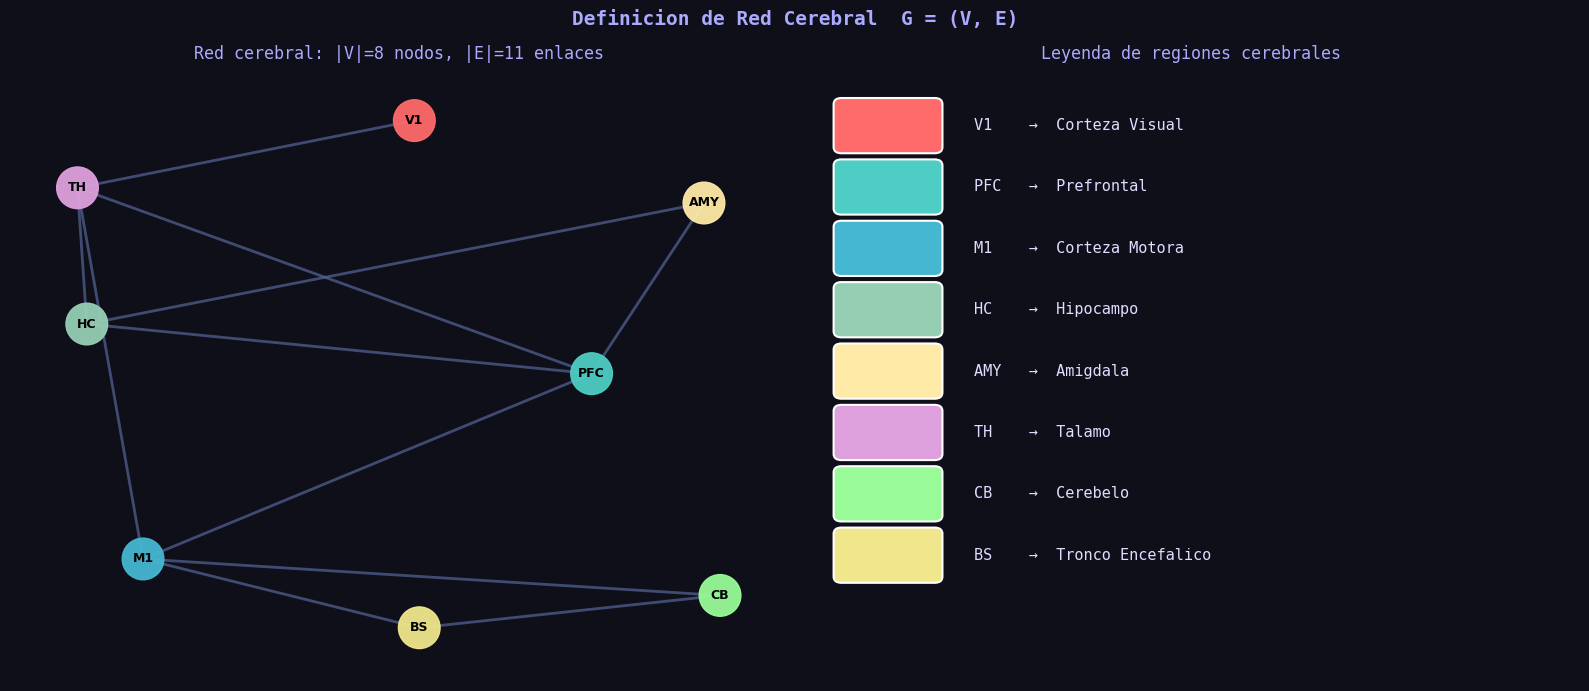

Maximo de enlaces posibles (red completa): 28
Densidad de la red: 0.39


In [2]:
# ============================================================
# CELDA 1: Definición de red — Red cerebral básica
# ============================================================

# Definimos conexiones anatómicas conocidas (simplificadas)
conexiones = [
    ('V1','TH'), ('PFC','HC'), ('PFC','AMY'), ('M1','CB'),
    ('M1','BS'), ('HC','AMY'), ('TH','V1'), ('TH','M1'),
    ('TH','PFC'), ('BS','CB'), ('PFC','M1'), ('HC','TH')
]

G = nx.Graph()
G.add_nodes_from(REGIONES)
G.add_edges_from(conexiones)

pos = nx.spring_layout(G, seed=42, k=2.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Definicion de Red Cerebral  G = (V, E)', fontsize=14, fontweight='bold', color='#aaaaff')

# --- Grafo cerebral ---
ax = axes[0]
ax.set_facecolor('#1a1a2e')
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#556699', width=2, alpha=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=COLORES, node_size=900, alpha=0.95)
nx.draw_networkx_labels(G, pos, ax=ax,
    font_color='black', font_size=9, font_weight='bold')
ax.set_title(f'Red cerebral: |V|={G.number_of_nodes()} nodos, |E|={G.number_of_edges()} enlaces',
             color='#aaaaff')
ax.axis('off')

# --- Leyenda de nodos ---
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.axis('off')
ax2.set_title('Leyenda de regiones cerebrales', color='#aaaaff')
for i, (abr, nombre, col) in enumerate(zip(REGIONES, NOMBRES, COLORES)):
    patch = mpatches.FancyBboxPatch((0.05, 0.87 - i*0.1), 0.12, 0.07,
        boxstyle='round,pad=0.01', facecolor=col, edgecolor='white', linewidth=1.5)
    ax2.add_patch(patch)
    ax2.text(0.22, 0.905 - i*0.1, f'{abr:4s}  →  {nombre}',
             va='center', fontsize=11, color='#ddddff')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fig1_definicion_red.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Maximo de enlaces posibles (red completa): {N*(N-1)//2}')
print(f'Densidad de la red: {G.number_of_edges() / (N*(N-1)//2):.2f}')

---
## 2. Redes No Dirigidas

En una **red no dirigida**, los enlaces no tienen orientación: si existe conexión entre $i$ y $j$, entonces también existe de $j$ hacia $i$.

$$A_{ij} = A_{ji} \quad \Rightarrow \quad \text{Matriz simétrica}$$

### Ejemplo cerebral
Las **conexiones anatómicas estructurales** (tractos de sustancia blanca medidos con tractografía por DTI) son no dirigidas: la fibra que conecta el hipocampo con la corteza prefrontal transmite señales en ambas direcciones.

### Propiedades
- **Grado** de un nodo: $k_i = \sum_j A_{ij}$ (número de conexiones)
- **Grado promedio**: $\langle k \rangle = \frac{2|E|}{N}$
- La suma de todos los grados = $2|E|$

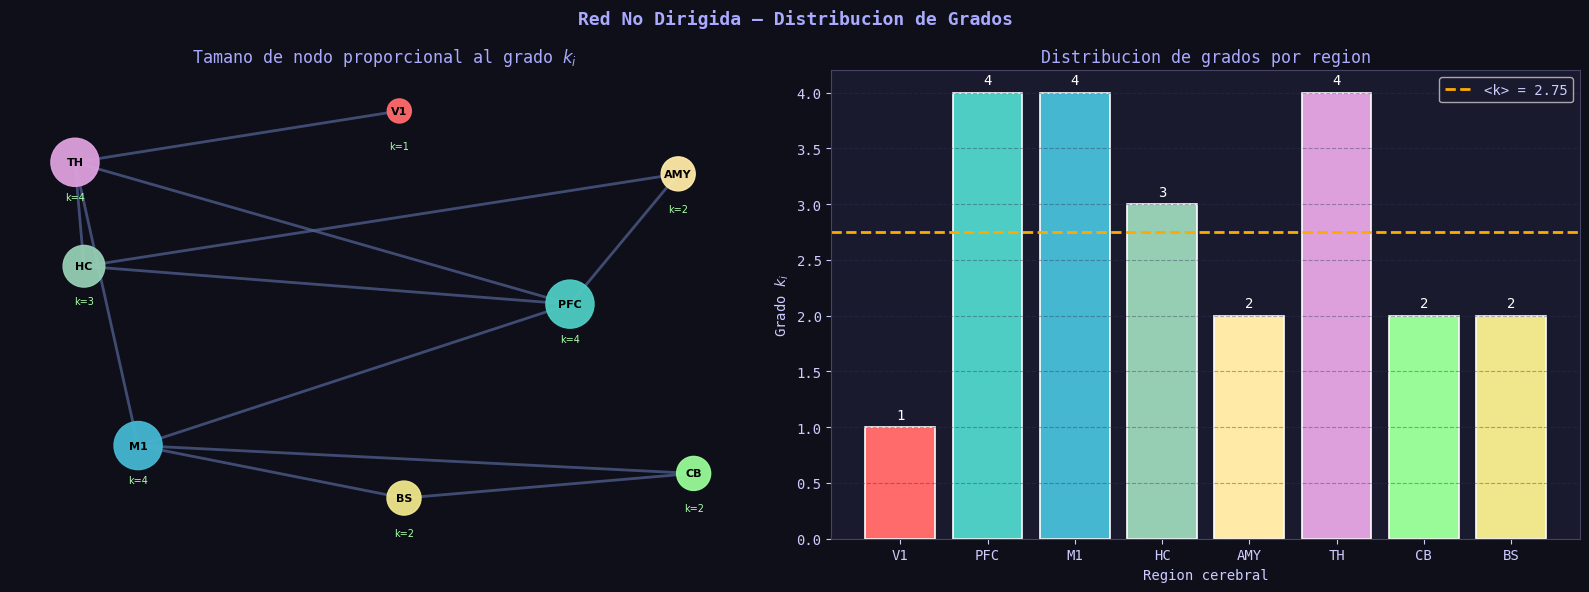

Grado de cada region:
  PFC  (Prefrontal          ): k = 4
  M1   (Corteza Motora      ): k = 4
  TH   (Talamo              ): k = 4
  HC   (Hipocampo           ): k = 3
  AMY  (Amigdala            ): k = 2
  CB   (Cerebelo            ): k = 2
  BS   (Tronco Encefalico   ): k = 2
  V1   (Corteza Visual      ): k = 1

Grado promedio <k> = 2.75


In [3]:
# ============================================================
# CELDA 2: Redes No Dirigidas — grados y distribución
# ============================================================

grados = dict(G.degree())
grado_vals = list(grados.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Red No Dirigida — Distribucion de Grados', fontsize=13, color='#aaaaff', fontweight='bold')

# --- Red con tamaño de nodo proporcional al grado ---
ax = axes[0]
ax.set_facecolor('#1a1a2e')
sizes = [grados[n]*300 for n in REGIONES]
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#556699', width=2, alpha=0.7)
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=COLORES, node_size=sizes, alpha=0.95)
nx.draw_networkx_labels(G, pos, ax=ax, font_color='black', font_size=8, font_weight='bold')
# Etiquetas de grado
grado_labels = {n: f'k={grados[n]}' for n in REGIONES}
offset_pos = {n: (p[0], p[1]-0.18) for n, p in pos.items()}
nx.draw_networkx_labels(G, offset_pos, labels=grado_labels, ax=ax,
    font_color='#aaffaa', font_size=7)
ax.set_title('Tamano de nodo proporcional al grado $k_i$', color='#aaaaff')
ax.axis('off')

# --- Distribución de grados ---
ax2 = axes[1]
bars = ax2.bar(REGIONES, grado_vals, color=COLORES, edgecolor='white', linewidth=1.2)
ax2.axhline(np.mean(grado_vals), color='#ffaa00', linestyle='--',
            linewidth=2, label=f'<k> = {np.mean(grado_vals):.2f}')
ax2.set_xlabel('Region cerebral')
ax2.set_ylabel('Grado $k_i$')
ax2.set_title('Distribucion de grados por region', color='#aaaaff')
ax2.legend()
ax2.grid(axis='y')
for bar, val in zip(bars, grado_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05, str(val),
             ha='center', va='bottom', fontsize=10, color='white')

plt.tight_layout()
plt.savefig('fig2_red_no_dirigida.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grado de cada region:')
for reg, k in sorted(grados.items(), key=lambda x: -x[1]):
    nombre = NOMBRES[REGIONES.index(reg)]
    print(f'  {reg:4s} ({nombre:20s}): k = {k}')
print(f'\nGrado promedio <k> = {np.mean(grado_vals):.2f}')

---
## 3. Representación con Matrices  |  4. Matriz de Adyacencia

Una red se puede representar algebraicamente mediante su **matriz de adyacencia** $A \in \mathbb{R}^{N \times N}$:

$$A_{ij} = \begin{cases} 1 & \text{si existe enlace entre } i \text{ y } j \\ 0 & \text{en caso contrario} \end{cases}$$

Para una red **no dirigida y sin pesos**, la matriz $A$ es:
- **Simétrica**: $A = A^T$
- **Binaria**: entradas 0 o 1
- **Sin diagonal principal**: $A_{ii} = 0$ (sin auto-conexiones)

### Propiedades algebraicas clave
- El vector de grados: $\mathbf{k} = A \cdot \mathbf{1}$ (suma de filas)
- El número de enlaces: $|E| = \frac{1}{2} \text{tr}(A^2)$
- Los **eigenvalores** de $A$ describen la dinámica de propagación en la red

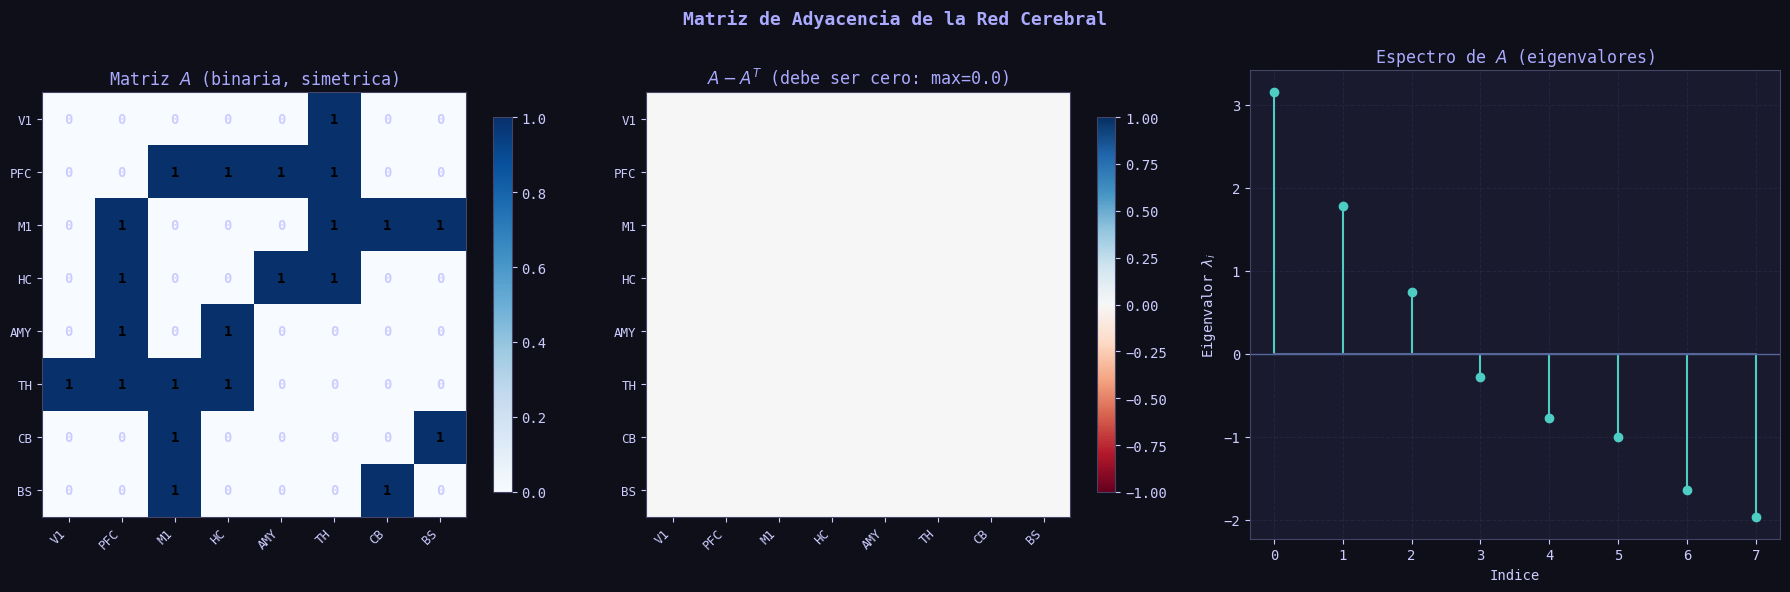

Matriz de adyacencia A:
     V1   PFC  M1   HC   AMY  TH   CB   BS 
V1   [  0    0    0    0    0    1    0    0]
PFC  [  0    0    1    1    1    1    0    0]
M1   [  0    1    0    0    0    1    1    1]
HC   [  0    1    0    0    1    1    0    0]
AMY  [  0    1    0    1    0    0    0    0]
TH   [  1    1    1    1    0    0    0    0]
CB   [  0    0    1    0    0    0    0    1]
BS   [  0    0    1    0    0    0    1    0]

A es simetrica: True
Eigenvalor maximo (radio espectral): 3.1598


In [4]:
# ============================================================
# CELDA 3: Matriz de Adyacencia
# ============================================================

A = nx.to_numpy_array(G, nodelist=REGIONES)

# Verificaciones algebraicas
grados_vec = A @ np.ones(N)
eigenvalores = np.linalg.eigvalsh(A)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Matriz de Adyacencia de la Red Cerebral', fontsize=13, color='#aaaaff', fontweight='bold')

# --- Heatmap de la matriz A ---
ax = axes[0]
im = ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(REGIONES, fontsize=9)
for i in range(N):
    for j in range(N):
        ax.text(j, i, int(A[i,j]), ha='center', va='center',
                color='black' if A[i,j] > 0.5 else '#ccccff', fontsize=10, fontweight='bold')
ax.set_title('Matriz $A$ (binaria, simetrica)', color='#aaaaff')
plt.colorbar(im, ax=ax, shrink=0.8)

# --- Visualizar A es simétrica: A - A^T = 0 ---
ax2 = axes[1]
diff = A - A.T
im2 = ax2.imshow(diff, cmap='RdBu', vmin=-1, vmax=1)
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(REGIONES, fontsize=9)
ax2.set_title(f'$A - A^T$ (debe ser cero: max={diff.max():.1f})', color='#aaaaff')
plt.colorbar(im2, ax=ax2, shrink=0.8)

# --- Eigenvalores ---
ax3 = axes[2]
ax3.stem(range(N), sorted(eigenvalores, reverse=True),
         linefmt='#4ecdc4', markerfmt='o', basefmt='#556699')
ax3.axhline(0, color='#556699', linewidth=1)
ax3.set_xlabel('Indice')
ax3.set_ylabel('Eigenvalor $\\lambda_i$')
ax3.set_title('Espectro de $A$ (eigenvalores)', color='#aaaaff')
ax3.grid()

plt.tight_layout()
plt.savefig('fig3_matriz_adyacencia.png', dpi=150, bbox_inches='tight')
plt.show()

print('Matriz de adyacencia A:')
print('     ' + '  '.join(f'{r:3s}' for r in REGIONES))
for i, reg in enumerate(REGIONES):
    row = '  '.join(f'{int(A[i,j]):3d}' for j in range(N))
    print(f'{reg:4s} [{row}]')
print(f'\nA es simetrica: {np.allclose(A, A.T)}')
print(f'Eigenvalor maximo (radio espectral): {eigenvalores.max():.4f}')

---
## 5. Redes Dirigidas

En una **red dirigida** (dígrafo), los enlaces tienen una dirección específica: $i \rightarrow j$ **no** implica $j \rightarrow i$.

$$A_{ij} \neq A_{ji} \quad \Rightarrow \quad \text{Matriz asimétrica en general}$$

### Ejemplo cerebral: flujo de información
En el cerebro, muchas conexiones tienen un sesgo direccional claro:
- El **tálamo** envía señales sensoriales a la corteza (→) pero la corteza también regula el tálamo (←)
- El **tronco encefálico** comanda los músculos a través de la médula espinal (→)
- El modelo de **red funcional** causal (Granger causality) es por definición dirigido

### Grado de entrada y salida
- **Grado de entrada** (in-degree): $k_i^{in} = \sum_j A_{ji}$ — cuántas regiones envían señal a $i$
- **Grado de salida** (out-degree): $k_i^{out} = \sum_j A_{ij}$ — cuántas regiones recibe señal desde $i$

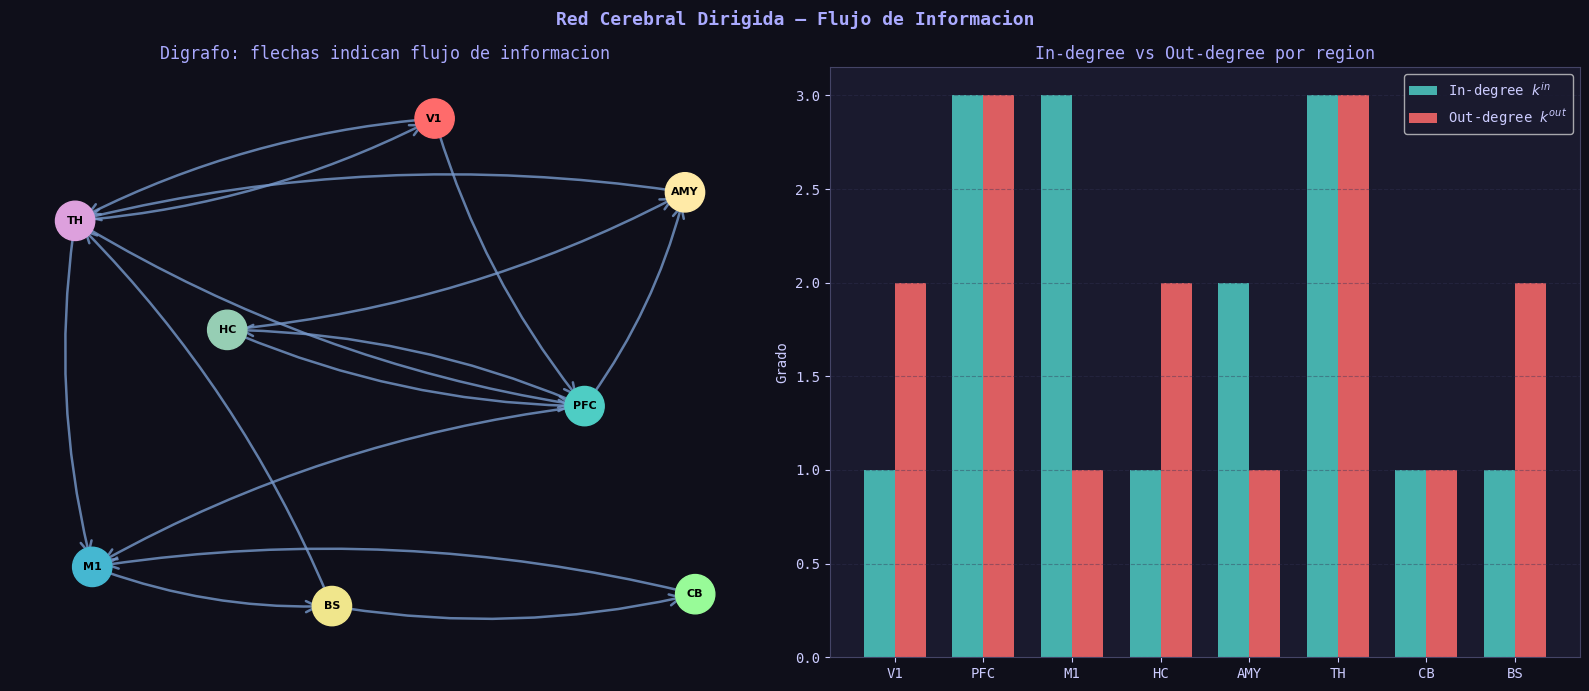

Region        | In-degree | Out-degree | Balance (out-in)
------------------------------------------------------------
V1     (Corteza Visual        ) |         1 |          2 | +1
PFC    (Prefrontal            ) |         3 |          3 | +0
M1     (Corteza Motora        ) |         3 |          1 | -2
HC     (Hipocampo             ) |         1 |          2 | +1
AMY    (Amigdala              ) |         2 |          1 | -1
TH     (Talamo                ) |         3 |          3 | +0
CB     (Cerebelo              ) |         1 |          1 | +0
BS     (Tronco Encefalico     ) |         1 |          2 | +1


In [5]:
# ============================================================
# CELDA 4: Redes Dirigidas
# ============================================================

# Creamos red dirigida con sesgo de flujo de informacion
DG = nx.DiGraph()
DG.add_nodes_from(REGIONES)

# Conexiones dirigidas: (origen, destino)
# Flujo de procesamiento sensoriomotor simplificado
conexiones_dir = [
    ('TH', 'V1'),  ('TH', 'M1'),   ('TH', 'PFC'),
    ('V1', 'PFC'), ('BS', 'TH'),   ('BS', 'CB'),
    ('PFC','HC'),  ('PFC','AMY'),  ('PFC','M1'),
    ('HC', 'AMY'), ('AMY','TH'),   ('CB', 'M1'),
    ('M1', 'BS'),  ('HC', 'PFC'),  ('V1', 'TH'),
]
DG.add_edges_from(conexiones_dir)

Ad = nx.to_numpy_array(DG, nodelist=REGIONES)
in_deg  = dict(DG.in_degree())
out_deg = dict(DG.out_degree())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Red Cerebral Dirigida — Flujo de Informacion', fontsize=13, color='#aaaaff', fontweight='bold')

# --- Dígrafo ---
ax = axes[0]
ax.set_facecolor('#1a1a2e')
pos_d = nx.spring_layout(DG, seed=42, k=2.2)
nx.draw_networkx_nodes(DG, pos_d, ax=ax, node_color=COLORES, node_size=800)
nx.draw_networkx_labels(DG, pos_d, ax=ax, font_color='black', font_size=8, font_weight='bold')
nx.draw_networkx_edges(DG, pos_d, ax=ax,
    edge_color='#7799cc', width=1.8, alpha=0.8,
    arrows=True, arrowsize=20, arrowstyle='->', connectionstyle='arc3,rad=0.1')
ax.set_title('Digrafo: flechas indican flujo de informacion', color='#aaaaff')
ax.axis('off')

# --- Grados in/out ---
ax2 = axes[1]
x_pos = np.arange(N)
width = 0.35
in_vals  = [in_deg[r]  for r in REGIONES]
out_vals = [out_deg[r] for r in REGIONES]
ax2.bar(x_pos - width/2, in_vals,  width, label='In-degree $k^{in}$',  color='#4ecdc4', alpha=0.85)
ax2.bar(x_pos + width/2, out_vals, width, label='Out-degree $k^{out}$', color='#ff6b6b', alpha=0.85)
ax2.set_xticks(x_pos); ax2.set_xticklabels(REGIONES)
ax2.set_ylabel('Grado')
ax2.set_title('In-degree vs Out-degree por region', color='#aaaaff')
ax2.legend()
ax2.grid(axis='y')

plt.tight_layout()
plt.savefig('fig4_red_dirigida.png', dpi=150, bbox_inches='tight')
plt.show()

print('Region        | In-degree | Out-degree | Balance (out-in)')
print('-'*60)
for r in REGIONES:
    bal = out_deg[r] - in_deg[r]
    sign = '+' if bal >= 0 else ''
    print(f'{r:6s} ({NOMBRES[REGIONES.index(r)]:22s}) | {in_deg[r]:9d} | {out_deg[r]:10d} | {sign}{bal}')

---
## 6. Análisis de Loop

Un **loop** (o ciclo) en una red dirigida es una trayectoria cerrada: $i \rightarrow j \rightarrow \cdots \rightarrow i$.

### Relevancia neurológica
Los loops en redes cerebrales son fundamentales:
- **Loop tálamo-cortical**: permite la percepción consciente y el ciclo vigilia-sueño
- **Loop cortico-basal-talámico**: involucrado en el aprendizaje motor
- **Loops de retroalimentación excitatorio-inhibitoria**: mantienen la oscilación de ritmos cerebrales

### Detección algebraica
La entrada $(A^k)_{ii}$ de la potencia $k$ de la matriz de adyacencia da el **número de caminos de longitud $k$ que regresan al nodo $i$**, es decir, el número de loops de longitud $k$ que pasan por $i$.

$$\text{Loops de longitud } k \text{ que pasan por } i = (A^k)_{ii}$$

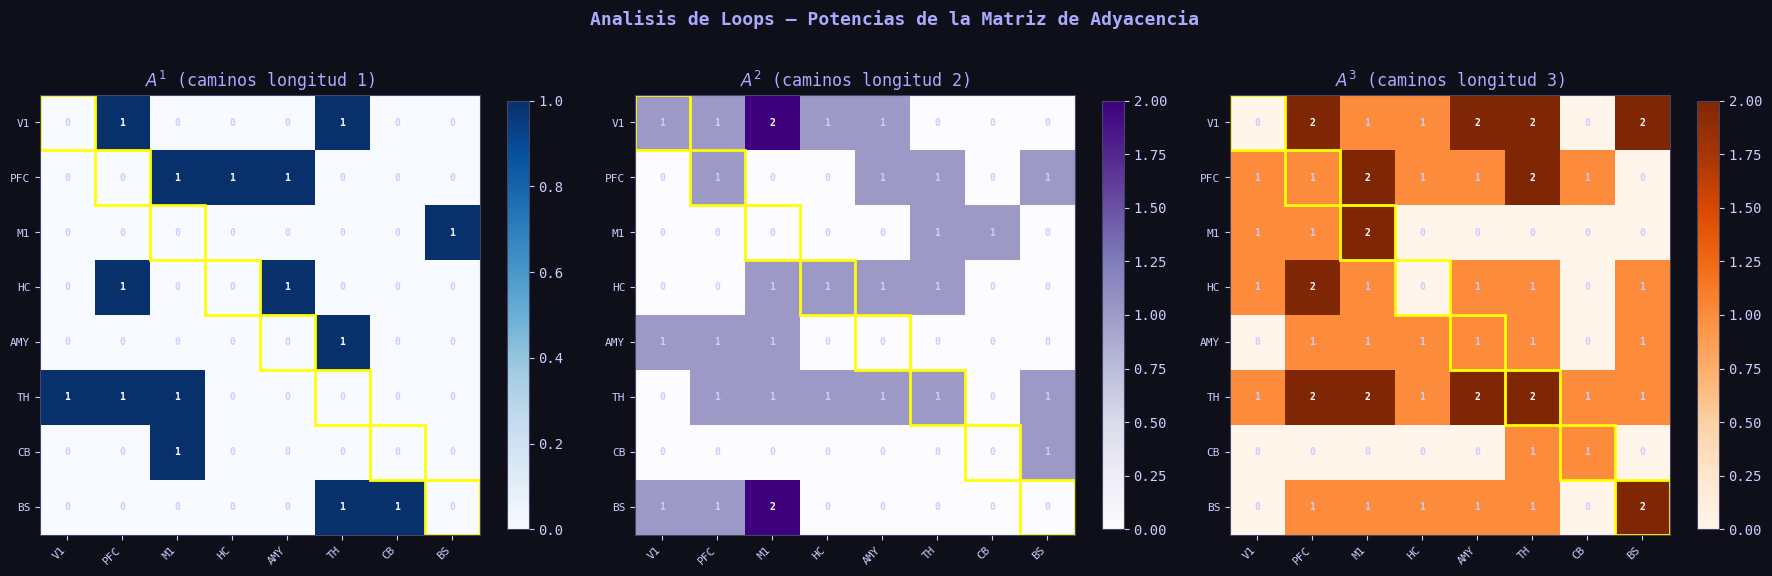

Loops detectados en la red dirigida cerebral:
Total de ciclos simples: 10

Ciclos de longitud <= 4:
  [2] HC -> PFC -> HC
  [2] TH -> V1 -> TH
  [3] M1 -> BS -> TH -> M1
  [3] M1 -> BS -> CB -> M1
  [3] TH -> PFC -> AMY -> TH
  [4] HC -> AMY -> TH -> PFC -> HC
  [4] M1 -> BS -> TH -> PFC -> M1
  [4] TH -> V1 -> PFC -> AMY -> TH

Loops de longitud 2 por nodo (diagonal de A^2):
  V1: 1 loop(s)
  PFC: 1 loop(s)
  M1: 0 loop(s)
  HC: 1 loop(s)
  AMY: 0 loop(s)
  TH: 1 loop(s)
  CB: 0 loop(s)
  BS: 0 loop(s)


In [6]:
# ============================================================
# CELDA 5: Analisis de Loops
# ============================================================

# Potencias de la matriz de adyacencia dirigida
Ad_mat = Ad.copy()
A2 = Ad_mat @ Ad_mat          # Caminos de longitud 2
A3 = A2 @ Ad_mat              # Caminos de longitud 3

# Ciclos en el digrafo
ciclos = list(nx.simple_cycles(DG))
ciclos_cortos = [c for c in ciclos if len(c) <= 4]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis de Loops — Potencias de la Matriz de Adyacencia', fontsize=13, color='#aaaaff', fontweight='bold')

titles = ['$A^1$ (caminos longitud 1)', '$A^2$ (caminos longitud 2)', '$A^3$ (caminos longitud 3)']
matrices = [Ad_mat, A2, A3]
cmaps = ['Blues', 'Purples', 'Oranges']

for ax, mat, title, cmap in zip(axes, matrices, titles, cmaps):
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(N)); ax.set_yticks(range(N))
    ax.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(REGIONES, fontsize=8)
    for i in range(N):
        for j in range(N):
            v = int(mat[i,j])
            ax.text(j, i, v, ha='center', va='center',
                    color='white' if mat[i,j] > mat.max()*0.5 else '#ccccff',
                    fontsize=7, fontweight='bold')
    ax.set_title(title, color='#aaaaff')
    # Resaltar diagonal (loops)
    for k in range(N):
        ax.add_patch(plt.Rectangle((k-0.5, k-0.5), 1, 1,
            fill=False, edgecolor='#ffff00', linewidth=2))
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('fig5_loops.png', dpi=150, bbox_inches='tight')
plt.show()

print('Loops detectados en la red dirigida cerebral:')
print(f'Total de ciclos simples: {len(ciclos)}')
print('\nCiclos de longitud <= 4:')
for c in sorted(ciclos_cortos, key=len):
    ruta = ' -> '.join(c) + ' -> ' + c[0]
    print(f'  [{len(c)}] {ruta}')

print('\nLoops de longitud 2 por nodo (diagonal de A^2):')
for i, reg in enumerate(REGIONES):
    print(f'  {reg}: {int(A2[i,i])} loop(s)')

---
## 7. Interacciones Directas e Indirectas

La matriz de adyacencia $A$ codifica únicamente las **interacciones directas** (de longitud 1). Sin embargo, en redes complejas son igualmente importantes las **interacciones indirectas**.

### Interpretación en redes cerebrales
- **Directa** ($A_{ij}$): la región $i$ hace sinapsis directamente con la región $j$
- **Indirecta de orden 2** ($(A^2)_{ij}$): existe un intermediario $k$ tal que $i \rightarrow k \rightarrow j$
- **Indirecta de orden $n$** ($(A^n)_{ij}$): existen $n-1$ intermediarios

### Distancia más corta (Shortest Path)
La **longitud del camino más corto** $d_{ij}$ entre dos nodos es el número mínimo de enlaces necesarios para ir de $i$ a $j$. En el cerebro, una $d_{ij}$ pequeña implica transmisión de información más rápida y eficiente.

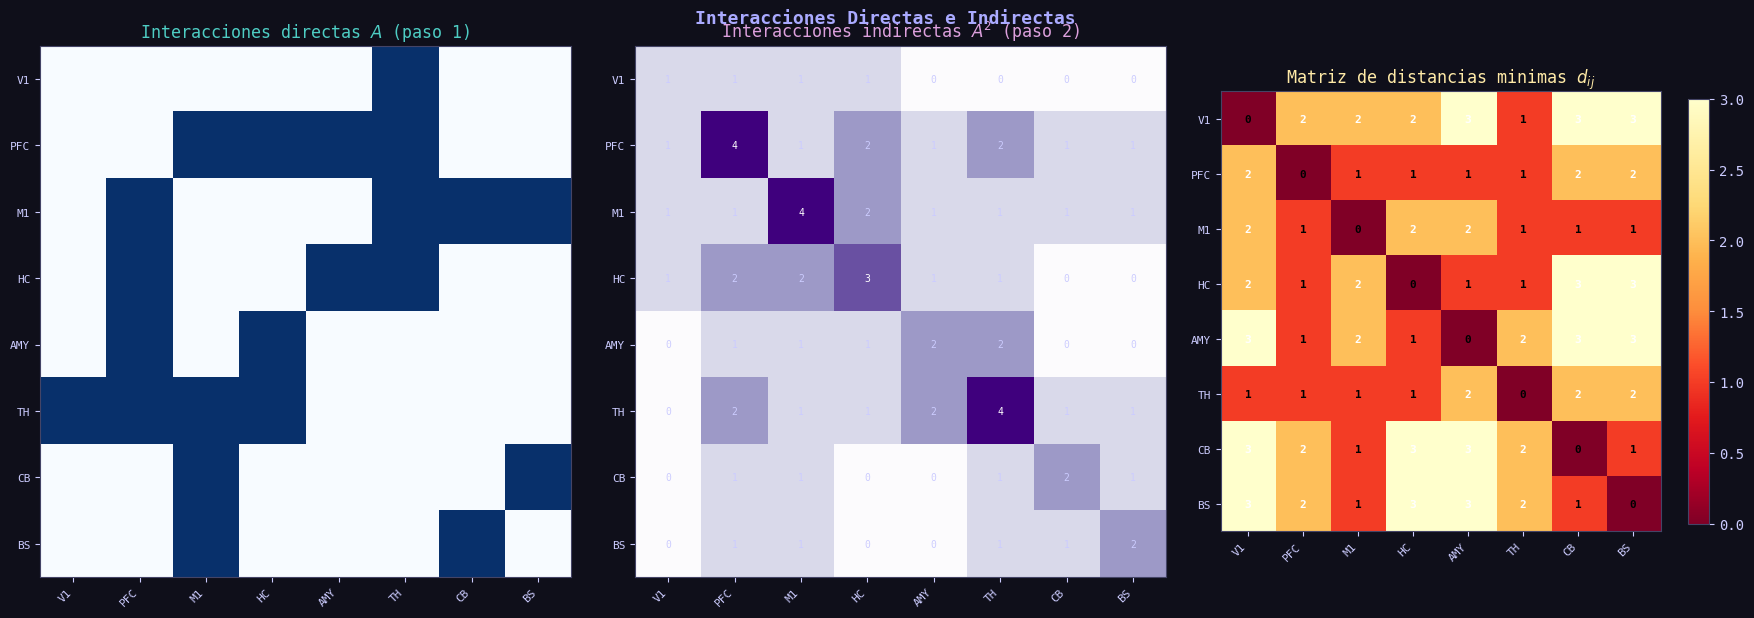

Camino medio <d> = 1.8571
Diametro de la red = 3
Eficiencia global = 1/<d> = 0.5385


In [7]:
# ============================================================
# CELDA 6: Interacciones Directas e Indirectas
# ============================================================

# Usamos grafo no dirigido para distancias
dist_matrix = np.zeros((N, N))
for i, u in enumerate(REGIONES):
    for j, v in enumerate(REGIONES):
        try:
            dist_matrix[i, j] = nx.shortest_path_length(G, u, v)
        except nx.NetworkXNoPath:
            dist_matrix[i, j] = np.inf

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Interacciones Directas e Indirectas', fontsize=13, color='#aaaaff', fontweight='bold')

# --- Interacciones directas (A) ---
ax = axes[0]
ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(REGIONES, fontsize=8)
ax.set_title('Interacciones directas $A$ (paso 1)', color='#4ecdc4')

# --- A^2 interacciones indirectas ---
A2_undir = A @ A
ax2 = axes[1]
ax2.imshow(A2_undir, cmap='Purples')
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(REGIONES, fontsize=8)
for i in range(N):
    for j in range(N):
        ax2.text(j, i, int(A2_undir[i,j]), ha='center', va='center',
                 color='white' if A2_undir[i,j] > A2_undir.max()/2 else '#ccccff', fontsize=7)
ax2.set_title('Interacciones indirectas $A^2$ (paso 2)', color='#dda0dd')

# --- Matriz de distancias ---
ax3 = axes[2]
im3 = ax3.imshow(dist_matrix, cmap='YlOrRd_r')
ax3.set_xticks(range(N)); ax3.set_yticks(range(N))
ax3.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=8)
ax3.set_yticklabels(REGIONES, fontsize=8)
for i in range(N):
    for j in range(N):
        v = int(dist_matrix[i,j]) if dist_matrix[i,j] != np.inf else 'inf'
        ax3.text(j, i, v, ha='center', va='center',
                 color='black' if dist_matrix[i,j] <= 1 else '#ffffff', fontsize=8, fontweight='bold')
ax3.set_title('Matriz de distancias minimas $d_{ij}$', color='#ffeaa7')
plt.colorbar(im3, ax=ax3, shrink=0.8)

plt.tight_layout()
plt.savefig('fig6_interacciones.png', dpi=150, bbox_inches='tight')
plt.show()

camino_medio = nx.average_shortest_path_length(G)
diametro = nx.diameter(G)
print(f'Camino medio <d> = {camino_medio:.4f}')
print(f'Diametro de la red = {diametro}')
print(f'Eficiencia global = 1/<d> = {1/camino_medio:.4f}')

---
## 8. Enlace, Dirección y Peso

Hasta ahora los enlaces eran binarios (0 o 1). Las redes reales tienen **enlaces ponderados** que codifican la intensidad de la interacción.

### Tipos de enlace en redes cerebrales

| Propiedad | Descripción | Ejemplo cerebral |
|-----------|-------------|------------------|
| **Existencia** | Hay o no hay conexión | ¿Existe sinapsis? |
| **Dirección** | Quién envía → quién recibe | Axón presináptico → postsináptico |
| **Peso (+)** | Fuerza de interacción excitadora | Sinapsis glutamatérgica |
| **Peso (−)** | Fuerza de interacción inhibidora | Sinapsis GABAérgica |

La **matriz de pesos** $W$ reemplaza a la matriz binaria $A$:
$$W_{ij} \in \mathbb{R}, \quad W_{ij} > 0 \text{ (excitatorio)}, \quad W_{ij} < 0 \text{ (inhibitorio)}$$

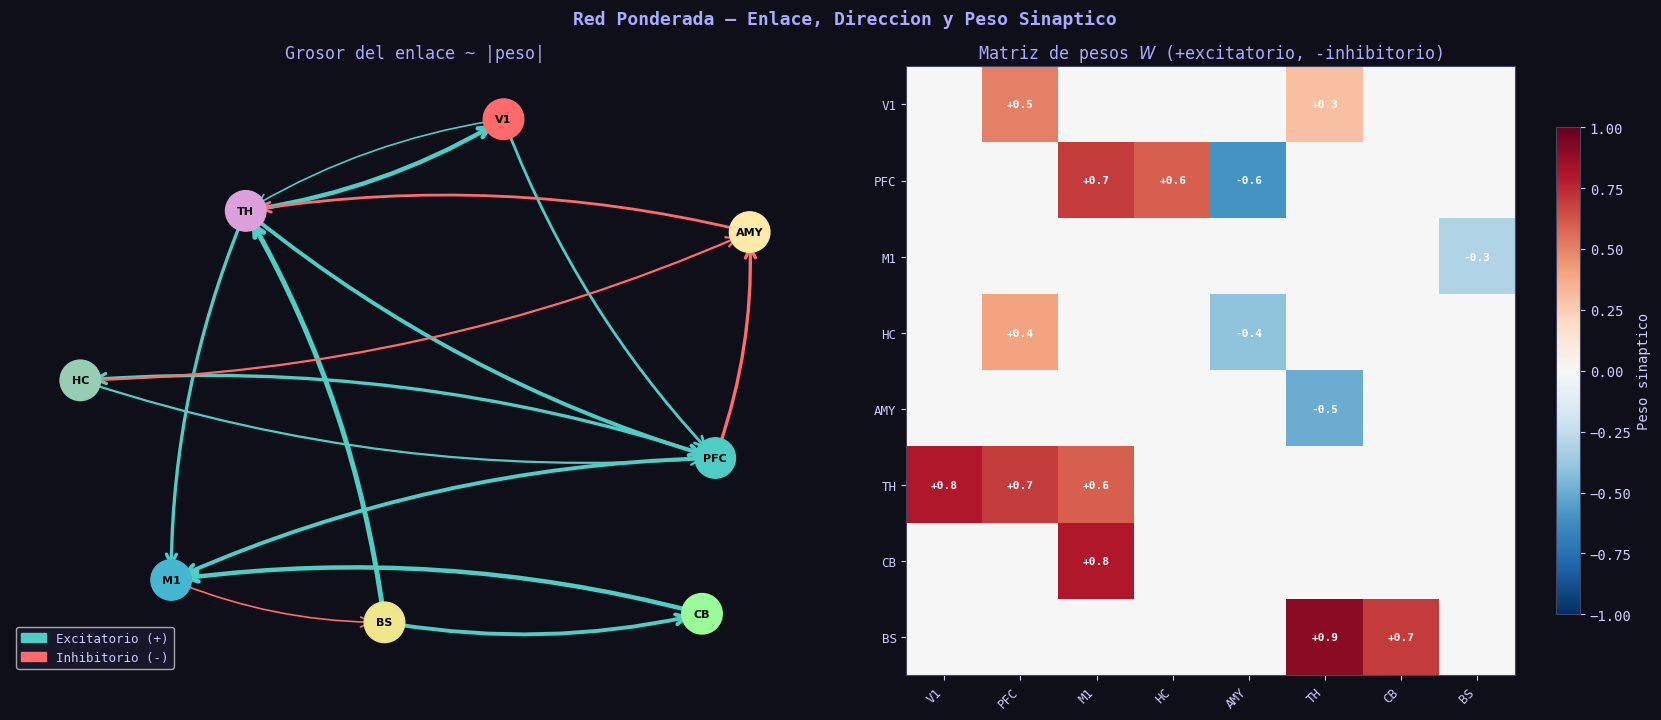

In [8]:
# ============================================================
# CELDA 7: Enlace, Direccion y Peso
# ============================================================

np.random.seed(7)

# Construimos matriz de pesos W (excitatorio + / inhibitorio -)
# Basado en la red dirigida DG, asignamos pesos biologicamente motivados
W = np.zeros((N, N))
pesos_exc = {  # Excitatorios (positivos)
    ('TH','V1'):0.8, ('TH','M1'):0.6, ('TH','PFC'):0.7,
    ('V1','PFC'):0.5, ('BS','TH'):0.9, ('BS','CB'):0.7,
    ('PFC','HC'):0.6, ('PFC','M1'):0.7, ('CB','M1'):0.8,
    ('HC','PFC'):0.4, ('V1','TH'):0.3,
}
pesos_inh = {  # Inhibitorios (negativos)
    ('PFC','AMY'):-0.6, ('HC','AMY'):-0.4,
    ('AMY','TH'):-0.5, ('M1','BS'):-0.3,
}
for (u,v), w in {**pesos_exc, **pesos_inh}.items():
    i, j = REGIONES.index(u), REGIONES.index(v)
    W[i,j] = w

# Red ponderada con networkx
GW = nx.DiGraph()
GW.add_nodes_from(REGIONES)
for (u,v), w in {**pesos_exc, **pesos_inh}.items():
    GW.add_edge(u, v, weight=w)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Red Ponderada — Enlace, Direccion y Peso Sinaptico', fontsize=13, color='#aaaaff', fontweight='bold')

# --- Red con pesos visualizados ---
ax = axes[0]
ax.set_facecolor('#1a1a2e')
pos_w = nx.spring_layout(GW, seed=42, k=2.2)
nx.draw_networkx_nodes(GW, pos_w, ax=ax, node_color=COLORES, node_size=850)
nx.draw_networkx_labels(GW, pos_w, ax=ax, font_color='black', font_size=8, font_weight='bold')
exc_edges = [(u,v) for (u,v), w in {**pesos_exc}.items()]
inh_edges = [(u,v) for (u,v), w in {**pesos_inh}.items()]
exc_widths = [abs(pesos_exc.get((u,v),0))*4 for (u,v) in exc_edges]
inh_widths = [abs(pesos_inh.get((u,v),0))*4 for (u,v) in inh_edges]
nx.draw_networkx_edges(GW, pos_w, edgelist=exc_edges, ax=ax,
    edge_color='#4ecdc4', width=exc_widths, arrows=True, arrowsize=18,
    connectionstyle='arc3,rad=0.1', arrowstyle='->')
nx.draw_networkx_edges(GW, pos_w, edgelist=inh_edges, ax=ax,
    edge_color='#ff6b6b', width=inh_widths, arrows=True, arrowsize=18,
    connectionstyle='arc3,rad=0.1', arrowstyle='->')
patch_e = mpatches.Patch(color='#4ecdc4', label='Excitatorio (+)')
patch_i = mpatches.Patch(color='#ff6b6b', label='Inhibitorio (-)')
ax.legend(handles=[patch_e, patch_i], loc='lower left', fontsize=9)
ax.set_title('Grosor del enlace ~ |peso|', color='#aaaaff')
ax.axis('off')

# --- Heatmap de la matriz de pesos W ---
ax2 = axes[1]
im = ax2.imshow(W, cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(REGIONES, fontsize=9)
for i in range(N):
    for j in range(N):
        if W[i,j] != 0:
            ax2.text(j, i, f'{W[i,j]:+.1f}', ha='center', va='center',
                     color='white', fontsize=8, fontweight='bold')
ax2.set_title('Matriz de pesos $W$ (+excitatorio, -inhibitorio)', color='#aaaaff')
plt.colorbar(im, ax=ax2, shrink=0.8, label='Peso sinaptico')

plt.tight_layout()
plt.savefig('fig7_pesos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Aplicación en Ecología — Analogía con Redes Cerebrales

Como se vio en la clase (Lotka-Volterra), la ecología teórica describió interacciones entre especies con las mismas herramientas matemáticas que usamos para redes.

### Tabla de analogías directas

| Ecología | Red cerebral |
|----------|--------------|
| Especie $i$ | Región cerebral / población neuronal $i$ |
| Abundancia $x_i$ | Tasa de disparo / actividad neuronal |
| Depredación (+/-) | Conexión excitatoria-inhibitoria (E-I) |
| Competencia (-/-) | Inhibición mutua entre poblaciones |
| Mutualismo (+/+) | Sincronización entre redes |
| Capacidad de carga $K$ | Tasa máxima de disparo (saturación) |
| Tasa de crecimiento $R$ | Excitabilidad neuronal |
| Caos determinista | Actividad epiléptica |

### Modelo de Wilson-Cowan (análogo a Lotka-Volterra)
El modelo neuronal más conocido para pares E-I es:

$$\tau_E \frac{dE}{dt} = -E + (1 - r_E E) \cdot S(w_{EE} E - w_{EI} I + P)$$
$$\tau_I \frac{dI}{dt} = -I + (1 - r_I I) \cdot S(w_{IE} E - w_{II} I)$$

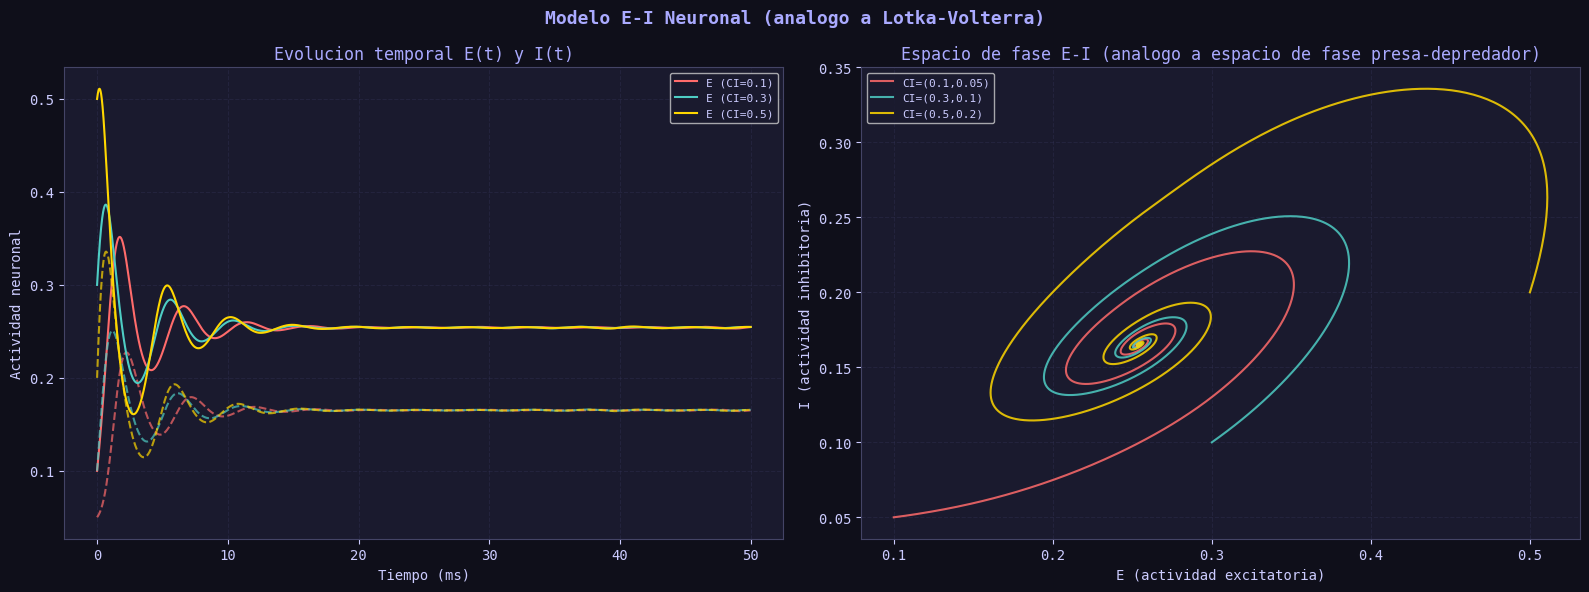

Analogia directa con el video:
  Presa    (x) <-> Poblacion excitatoria (E)
  Depredador(y) <-> Poblacion inhibitoria (I)
  Los ciclos en el espacio de fase son el mismo fenomeno matematico


In [9]:
# ============================================================
# CELDA 8: Aplicacion en Ecologia — Modelo E-I (Wilson-Cowan)
# analogia directa al Lotka-Volterra del video
# ============================================================

def sigmoid(x, a=1.2, theta=2.8):
    return 1 / (1 + np.exp(-a*(x - theta)))

def wilson_cowan(t, y, wEE=10, wEI=12, wIE=8, wII=3, P=1.5, tauE=1, tauI=1):
    E, I = y
    rE = max(0, min(1, E))
    rI = max(0, min(1, I))
    dE = (-E + (1 - 0.5*rE) * sigmoid(wEE*E - wEI*I + P)) / tauE
    dI = (-I + (1 - 0.5*rI) * sigmoid(wIE*E - wII*I    )) / tauI
    return [dE, dI]

t_span = (0, 50)
t_eval = np.linspace(0, 50, 5000)

# Condiciones iniciales: igual que Lotka-Volterra
# E = poblacion excitatoria (~ presa), I = inhibitoria (~ depredador)
cis = [(0.1, 0.05), (0.3, 0.1), (0.5, 0.2)]
colores_ci = ['#ff6b6b', '#4ecdc4', '#ffd700']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Modelo E-I Neuronal (analogo a Lotka-Volterra)', fontsize=13, color='#aaaaff', fontweight='bold')

ax1, ax2 = axes
for ci, col in zip(cis, colores_ci):
    sol = solve_ivp(wilson_cowan, t_span, list(ci), t_eval=t_eval, method='RK45')
    ax1.plot(sol.t, sol.y[0], color=col, lw=1.5, label=f'E (CI={ci[0]})')
    ax1.plot(sol.t, sol.y[1], color=col, lw=1.5, linestyle='--', alpha=0.7)
    ax2.plot(sol.y[0], sol.y[1], color=col, lw=1.5, label=f'CI=({ci[0]},{ci[1]})', alpha=0.85)

ax1.set_xlabel('Tiempo (ms)')
ax1.set_ylabel('Actividad neuronal')
ax1.set_title('Evolucion temporal E(t) y I(t)', color='#aaaaff')
ax1.legend(fontsize=8)
ax1.grid()
patch_e = mpatches.Patch(color='gray', label='-- = I (inhibitoria)')
ax1.legend(fontsize=8)

ax2.set_xlabel('E (actividad excitatoria)')
ax2.set_ylabel('I (actividad inhibitoria)')
ax2.set_title('Espacio de fase E-I (analogo a espacio de fase presa-depredador)', color='#aaaaff')
ax2.legend(fontsize=8)
ax2.grid()

plt.tight_layout()
plt.savefig('fig8_wilson_cowan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Analogia directa con el video:')
print('  Presa    (x) <-> Poblacion excitatoria (E)')
print('  Depredador(y) <-> Poblacion inhibitoria (I)')
print('  Los ciclos en el espacio de fase son el mismo fenomeno matematico')

---
## 10. Matriz Comunitaria

La **matriz comunitaria** (o **matriz jacobiana de comunidad**) $M$ describe cómo el crecimiento de la especie (o nodo) $j$ afecta a la especie $i$ en el punto de equilibrio:

$$M_{ij} = \frac{\partial f_i}{\partial x_j}\bigg|_{x^*}$$

donde $f_i$ es la dinámica de la variable de estado $x_i$.

### Interpretación de los signos
| Signo de $M_{ij}$ | Significado | Ejemplo neuronal |
|:-----------------:|-------------|------------------|
| $M_{ij} > 0$ | $j$ beneficia a $i$ | $j$ excita a $i$ |
| $M_{ij} < 0$ | $j$ perjudica a $i$ | $j$ inhibe a $i$ |
| $M_{ij} = 0$ | Sin interacción | No hay sinapsis |

La **estructura de signos** de $M$ determina la topología funcional de la red (idéntico a lo que el profesor mostró con los tipos de interacción).

### Relación con la estabilidad
El sistema es **estable** si **todos los eigenvalores** de $M$ tienen parte real negativa: $\text{Re}(\lambda_i) < 0$ para todo $i$.

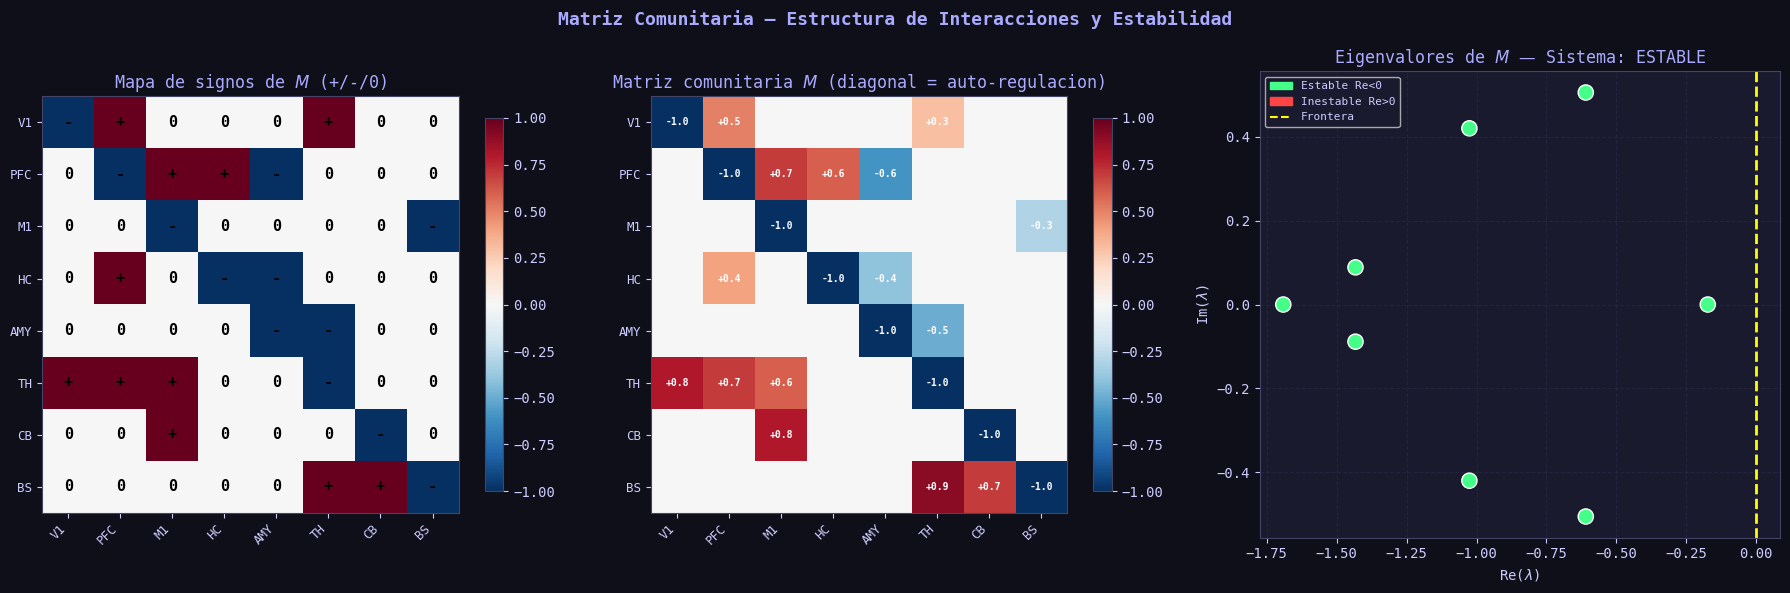

Eigenvalores de M:
  lambda_1 = -0.1736 + +0.0000j  [estable]
  lambda_2 = -0.6096 + +0.5058j  [estable]
  lambda_3 = -0.6096 + -0.5058j  [estable]
  lambda_4 = -1.0256 + +0.4204j  [estable]
  lambda_5 = -1.0256 + -0.4204j  [estable]
  lambda_6 = -1.4327 + +0.0886j  [estable]
  lambda_7 = -1.4327 + -0.0886j  [estable]
  lambda_8 = -1.6908 + +0.0000j  [estable]

Sistema global: ESTABLE


In [10]:
# ============================================================
# CELDA 9: Matriz Comunitaria
# ============================================================

# Construimos la matriz comunitaria M a partir de W
# con auto-regulacion negativa en la diagonal (cada region se auto-inhibe)
M = W.copy()
np.fill_diagonal(M, -1.0)  # Auto-regulacion negativa (estabilizador)

eigenvals = np.linalg.eigvals(M)
estable = np.all(np.real(eigenvals) < 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Matriz Comunitaria — Estructura de Interacciones y Estabilidad', fontsize=13, color='#aaaaff', fontweight='bold')

# --- Mapa de signos ---
ax = axes[0]
sign_M = np.sign(M)
sign_cmap = plt.cm.RdBu_r
im = ax.imshow(sign_M, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(REGIONES, fontsize=9)
for i in range(N):
    for j in range(N):
        s = '+' if sign_M[i,j] > 0 else ('-' if sign_M[i,j] < 0 else '0')
        ax.text(j, i, s, ha='center', va='center',
                color='black', fontsize=11, fontweight='bold')
ax.set_title('Mapa de signos de $M$ (+/-/0)', color='#aaaaff')
plt.colorbar(im, ax=ax, shrink=0.8)

# --- Matriz M completa ---
ax2 = axes[1]
im2 = ax2.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(REGIONES, fontsize=9)
for i in range(N):
    for j in range(N):
        if M[i,j] != 0:
            ax2.text(j, i, f'{M[i,j]:+.1f}', ha='center', va='center',
                     color='white', fontsize=7, fontweight='bold')
ax2.set_title('Matriz comunitaria $M$ (diagonal = auto-regulacion)', color='#aaaaff')
plt.colorbar(im2, ax=ax2, shrink=0.8)

# --- Eigenvalores en el plano complejo ---
ax3 = axes[2]
col_eig = ['#ff4444' if np.real(e) >= 0 else '#44ff88' for e in eigenvals]
ax3.scatter(np.real(eigenvals), np.imag(eigenvals), c=col_eig, s=120, zorder=5, edgecolors='white')
ax3.axvline(0, color='#ffff00', linewidth=2, linestyle='--', label='Frontera estabilidad')
ax3.set_xlabel('Re($\\lambda$)')
ax3.set_ylabel('Im($\\lambda$)')
ax3.set_title(f'Eigenvalores de $M$ — Sistema: {"ESTABLE" if estable else "INESTABLE"}', color='#aaaaff')
ax3.legend()
ax3.grid()
patch_s = mpatches.Patch(color='#44ff88', label='Estable Re<0')
patch_u = mpatches.Patch(color='#ff4444', label='Inestable Re>0')
ax3.legend(handles=[patch_s, patch_u, plt.Line2D([0],[0], color='#ffff00',
           linestyle='--', label='Frontera')], fontsize=8)

plt.tight_layout()
plt.savefig('fig9_matriz_comunitaria.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Eigenvalores de M:')
for i, e in enumerate(sorted(eigenvals, key=lambda x: np.real(x), reverse=True)):
    estado = 'INESTABLE' if np.real(e) >= 0 else 'estable'
    print(f'  lambda_{i+1} = {np.real(e):+.4f} + {np.imag(e):+.4f}j  [{estado}]')
print(f'\nSistema global: {"ESTABLE" if estable else "INESTABLE"}')

---
## 11. El Problema Complejidad-Estabilidad

Robert May (1972) demostró un resultado contraintuitivo: **redes más complejas tienden a ser menos estables**.

Para una red aleatoria de $N$ especies con:
- Conectividad $C$ (fracción de pares con interacción)
- Fuerza promedio de interacción $\sigma$

El criterio de estabilidad de May es:
$$\sigma \sqrt{NC} < 1$$

Cuando se viola: $\sigma\sqrt{NC} > 1 \Rightarrow$ **inestabilidad**.

### En el cerebro: el dilema E/I
El cerebro opera en un régimen cercano a la **criticidad** (frontera entre estabilidad e inestabilidad), lo que maximiza:
- Rango dinámico (sensibilidad a estímulos)
- Capacidad de procesamiento de información
- Flexibilidad cognitiva

La **epilepsia** puede interpretarse como una ruptura del equilibrio E/I: la red cruza la frontera hacia la inestabilidad.

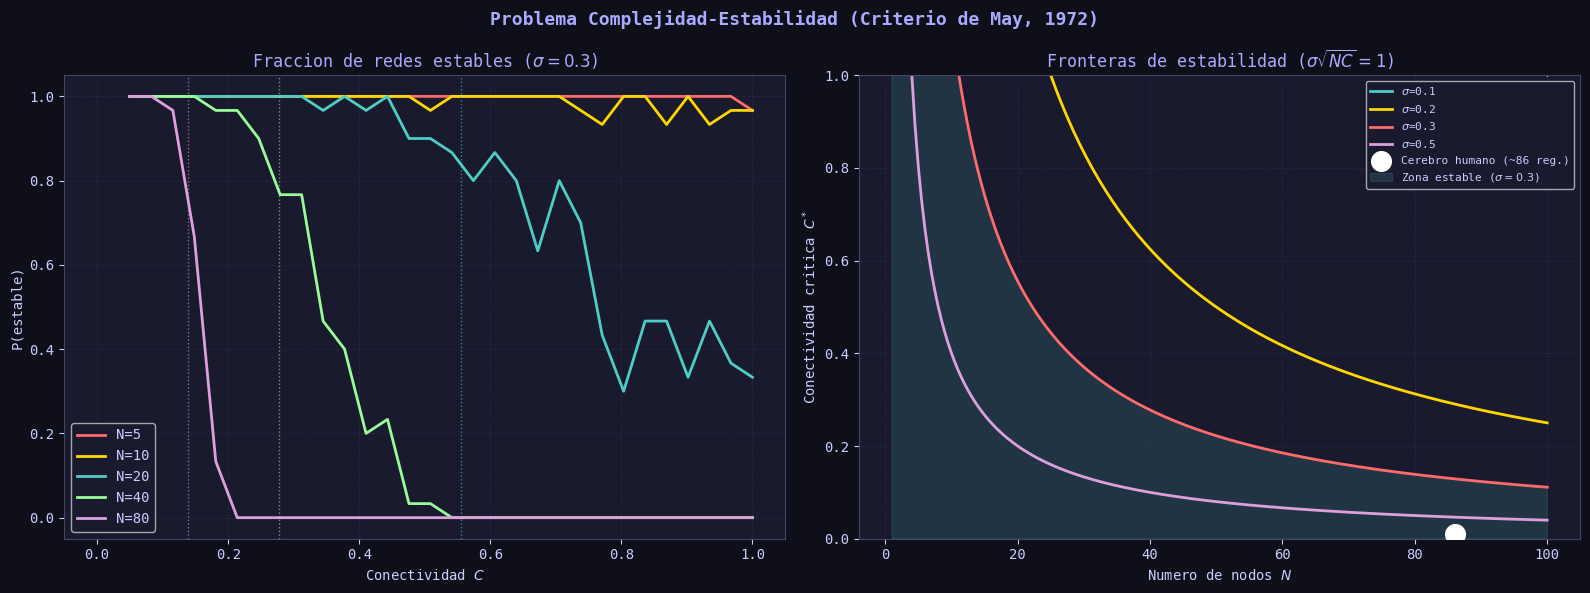

Criterio de May: sigma * sqrt(N*C) < 1 => estabilidad
Para N=86, C=0.01, sigma=0.2:
  sigma*sqrt(N*C) = 0.1855 -> ESTABLE


In [11]:
# ============================================================
# CELDA 10: El Problema Complejidad-Estabilidad (criterio de May)
# ============================================================

np.random.seed(42)

Ns = [5, 10, 20, 40, 80]  # Tamanos de red
Cs = np.linspace(0.05, 1.0, 30)  # Conectividades
sigma = 0.3  # Fuerza de interaccion fija

# Para cada (N, C) -> fraccion de simulaciones estables
n_sim = 30
results = {}
for N_may in Ns:
    stab = []
    for C in Cs:
        count_stable = 0
        for _ in range(n_sim):
            M_rand = np.zeros((N_may, N_may))
            for i in range(N_may):
                for j in range(N_may):
                    if i != j and np.random.rand() < C:
                        M_rand[i,j] = np.random.normal(0, sigma)
                M_rand[i,i] = -1  # auto-regulacion
            eigs = np.linalg.eigvals(M_rand)
            if np.all(np.real(eigs) < 0):
                count_stable += 1
        stab.append(count_stable / n_sim)
    results[N_may] = stab

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Problema Complejidad-Estabilidad (Criterio de May, 1972)', fontsize=13, color='#aaaaff', fontweight='bold')

# --- Fraccion estable vs conectividad ---
ax = axes[0]
paleta = ['#ff6b6b','#ffd700','#4ecdc4','#98fb98','#dda0dd']
for (N_may, stab), col in zip(results.items(), paleta):
    ax.plot(Cs, stab, color=col, linewidth=2, label=f'N={N_may}')
    # Frontera de May
    C_crit = 1 / (sigma**2 * N_may)
    if C_crit <= 1:
        ax.axvline(C_crit, color=col, linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlabel('Conectividad $C$')
ax.set_ylabel('P(estable)')
ax.set_title('Fraccion de redes estables ($\\sigma=0.3$)', color='#aaaaff')
ax.legend()
ax.grid()
ax.axvline(0, color='white', alpha=0)

# --- Diagrama de May: sigma*sqrt(N*C) ---
ax2 = axes[1]
N_range = np.linspace(1, 100, 200)
sigma_vals = [0.1, 0.2, 0.3, 0.5]
paleta2 = ['#4ecdc4','#ffd700','#ff6b6b','#dda0dd']
for sig, col in zip(sigma_vals, paleta2):
    C_crit = 1 / (sig**2 * N_range)
    ax2.plot(N_range, C_crit, color=col, linewidth=2, label=f'$\\sigma$={sig}')
    # Zona estable = debajo de la curva

# Marcar cerebro humano aproximado
N_brain, C_brain, sigma_brain = 86, 0.01, 0.2
ax2.scatter([N_brain], [C_brain], color='white', s=200, zorder=5, label='Cerebro humano (~86 reg.)')
ax2.fill_between(N_range, 0, 1/(0.3**2 * N_range), alpha=0.15, color='#4ecdc4', label='Zona estable ($\\sigma=0.3$)')
ax2.set_xlabel('Numero de nodos $N$')
ax2.set_ylabel('Conectividad critica $C^*$')
ax2.set_title('Fronteras de estabilidad ($\\sigma\\sqrt{NC}=1$)', color='#aaaaff')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8)
ax2.grid()

plt.tight_layout()
plt.savefig('fig10_complejidad_estabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Criterio de May: sigma * sqrt(N*C) < 1 => estabilidad')
print(f'Para N={N_brain}, C={C_brain}, sigma={sigma_brain}:')
print(f'  sigma*sqrt(N*C) = {sigma_brain * np.sqrt(N_brain*C_brain):.4f} -> {"ESTABLE" if sigma_brain*np.sqrt(N_brain*C_brain) < 1 else "INESTABLE"}')

---
## 12. Caso General — Mapa Logístico en Red Acoplada

Generalizando el mapa logístico del video a una **red de N nodos acoplados**, la dinámica de cada región cerebral $i$ es:

$$x_i^{(n+1)} = R_i \cdot x_i^{(n)} \cdot \left(1 - x_i^{(n)}\right) + \varepsilon \sum_j W_{ij} \cdot x_j^{(n)}$$

- El **primer término** es la dinámica logística propia de cada región
- El **segundo término** es el acoplamiento con las demás regiones vía la matriz de pesos $W$
- $\varepsilon$ es la fuerza de acoplamiento global

### Estados del sistema según $R$
Igual que en el video, el comportamiento depende de $R$:
- $R < 1$: extinción (silencio neuronal)
- $1 < R < 3$: punto fijo (estado de reposo)
- $R \approx 3.4$: oscilaciones rítmicas (ritmos cerebrales)
- $R > 3.57$: caos (actividad epiléptica)

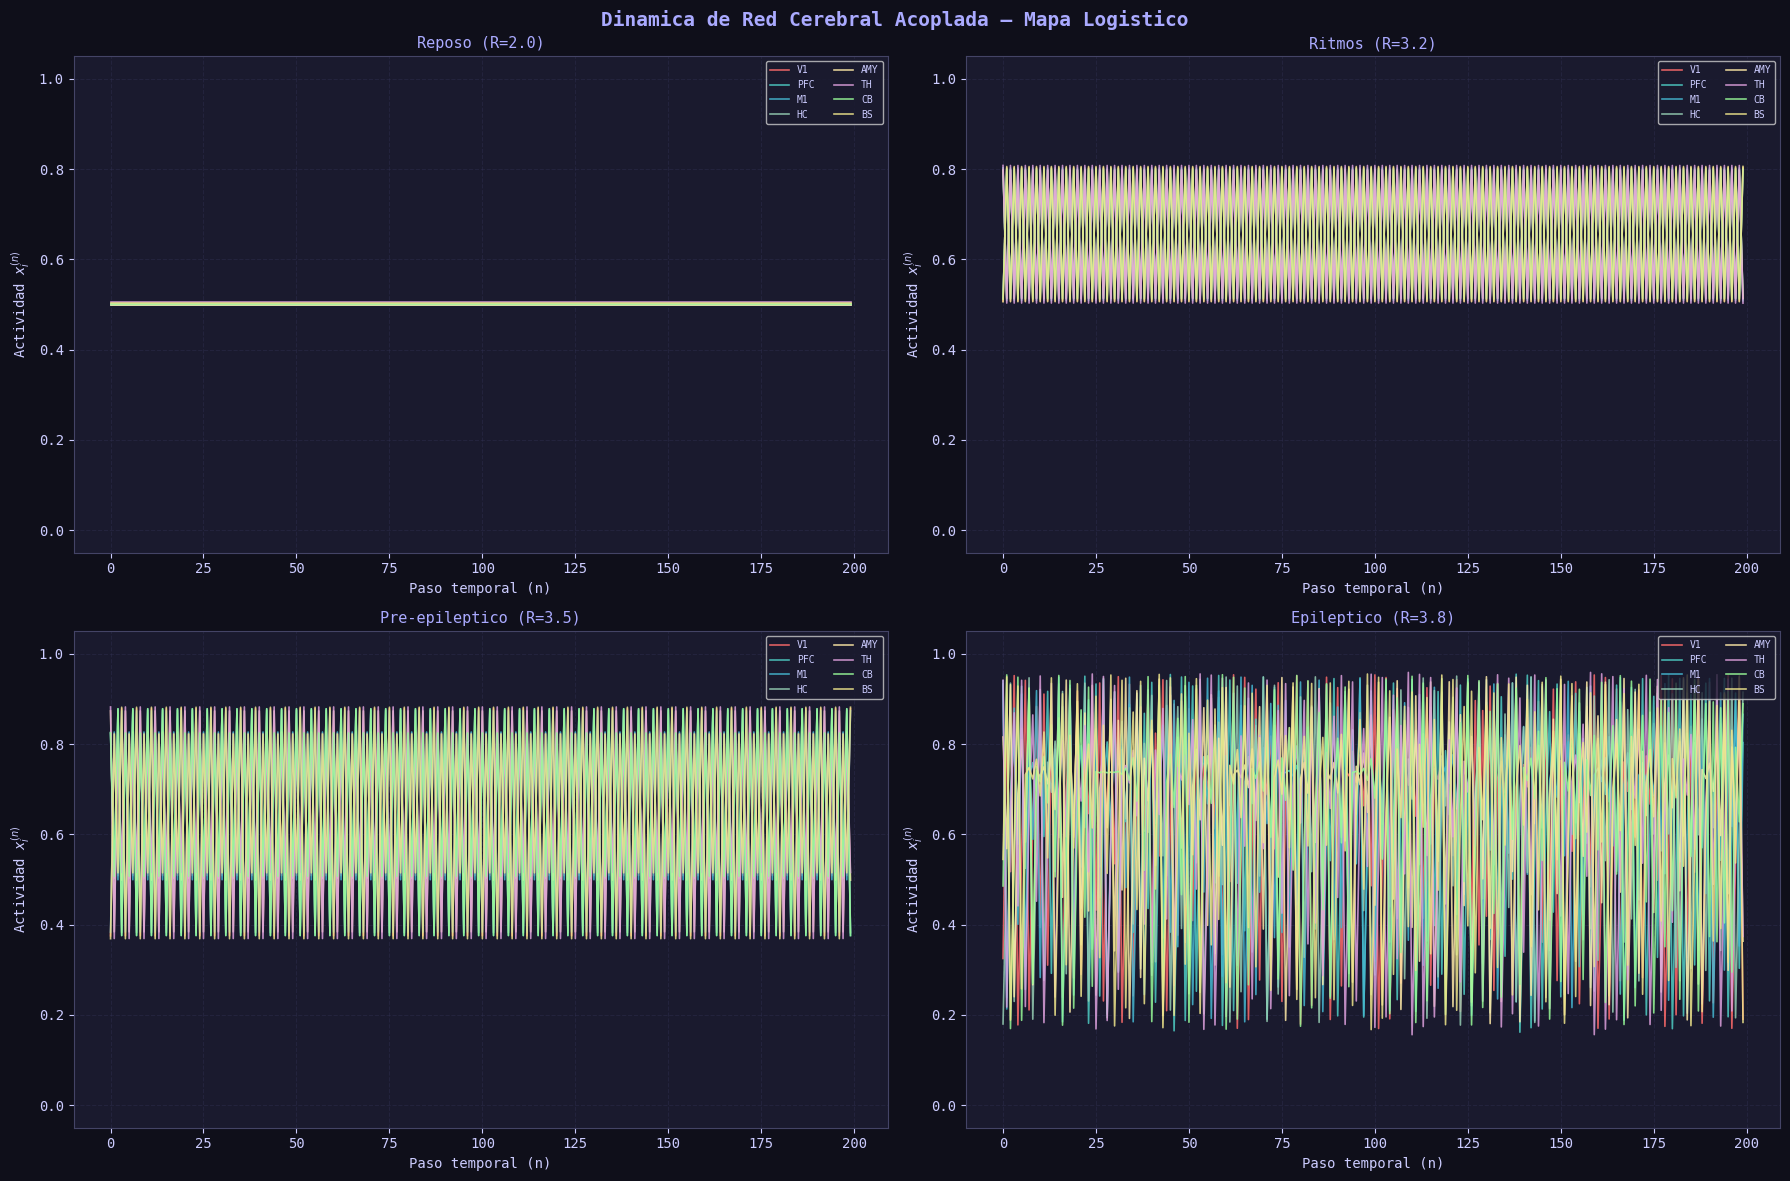

Se observan exactamente los 4 regimenes del video de clase,
pero ahora para CADA region cerebral de la red acoplada.


In [12]:
# ============================================================
# CELDA 11: Caso General — Red acoplada de N regiones cerebrales
# ============================================================

def simular_red_logistica(W_acop, R_vals, x0, T=200, T_transient=100, eps=0.05):
    N_nodos = len(x0)
    x = x0.copy()
    hist = []
    for t in range(T + T_transient):
        x_new = R_vals * x * (1 - x) + eps * (W_acop @ x)
        x_new = np.clip(x_new, 0, 1)
        x = x_new
        if t >= T_transient:
            hist.append(x.copy())
    return np.array(hist)

# Matriz de acoplamiento normalizada
W_norm = W / (np.abs(W).max() + 1e-9) * 0.1

R_escenarios = {
    'Reposo (R=2.0)':      np.full(N, 2.0),
    'Ritmos (R=3.2)':      np.full(N, 3.2),
    'Pre-epileptico (R=3.5)': np.full(N, 3.5),
    'Epileptico (R=3.8)':  np.full(N, 3.8),
}

np.random.seed(7)
x0 = np.random.uniform(0.1, 0.5, N)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Dinamica de Red Cerebral Acoplada — Mapa Logistico', fontsize=14, color='#aaaaff', fontweight='bold')
axes = axes.flatten()

paleta_nodos = COLORES[:N]

for ax, (titulo, R_vec) in zip(axes, R_escenarios.items()):
    hist = simular_red_logistica(W_norm, R_vec, x0)
    for i, (reg, col) in enumerate(zip(REGIONES, paleta_nodos)):
        ax.plot(hist[:, i], color=col, lw=1.2, label=reg, alpha=0.85)
    ax.set_xlabel('Paso temporal (n)')
    ax.set_ylabel('Actividad $x_i^{(n)}$')
    ax.set_title(titulo, color='#aaaaff', fontsize=11)
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.set_ylim(-0.05, 1.05)
    ax.grid()

plt.tight_layout()
plt.savefig('fig11_red_acoplada.png', dpi=150, bbox_inches='tight')
plt.show()
print('Se observan exactamente los 4 regimenes del video de clase,')
print('pero ahora para CADA region cerebral de la red acoplada.')

---
## 13. Caso con Comportamiento Adaptativo

El cerebro no es un sistema estático: los pesos sinápticos **cambian con el tiempo** mediante la **plasticidad sináptica** (Regla de Hebb, STDP). Esto es el equivalente cerebral del "comportamiento adaptativo" en ecología.

### Regla de Hebb (simplificada)
"Neuronas que se activan juntas, se conectan más fuerte":

$$\frac{dW_{ij}}{dt} = \eta \cdot x_i \cdot x_j - \delta \cdot W_{ij}$$

- $\eta$: tasa de aprendizaje (análogo a tasa de adaptación en ecología)
- $\delta$: decaimiento sináptico (análogo a mortalidad en Lotka-Volterra)

### Consecuencia dinámica
Con plasticidad, el sistema puede **auto-organizarse** hacia estados estables aunque los parámetros iniciales fueran caóticos. La red "aprende" a ser estable.

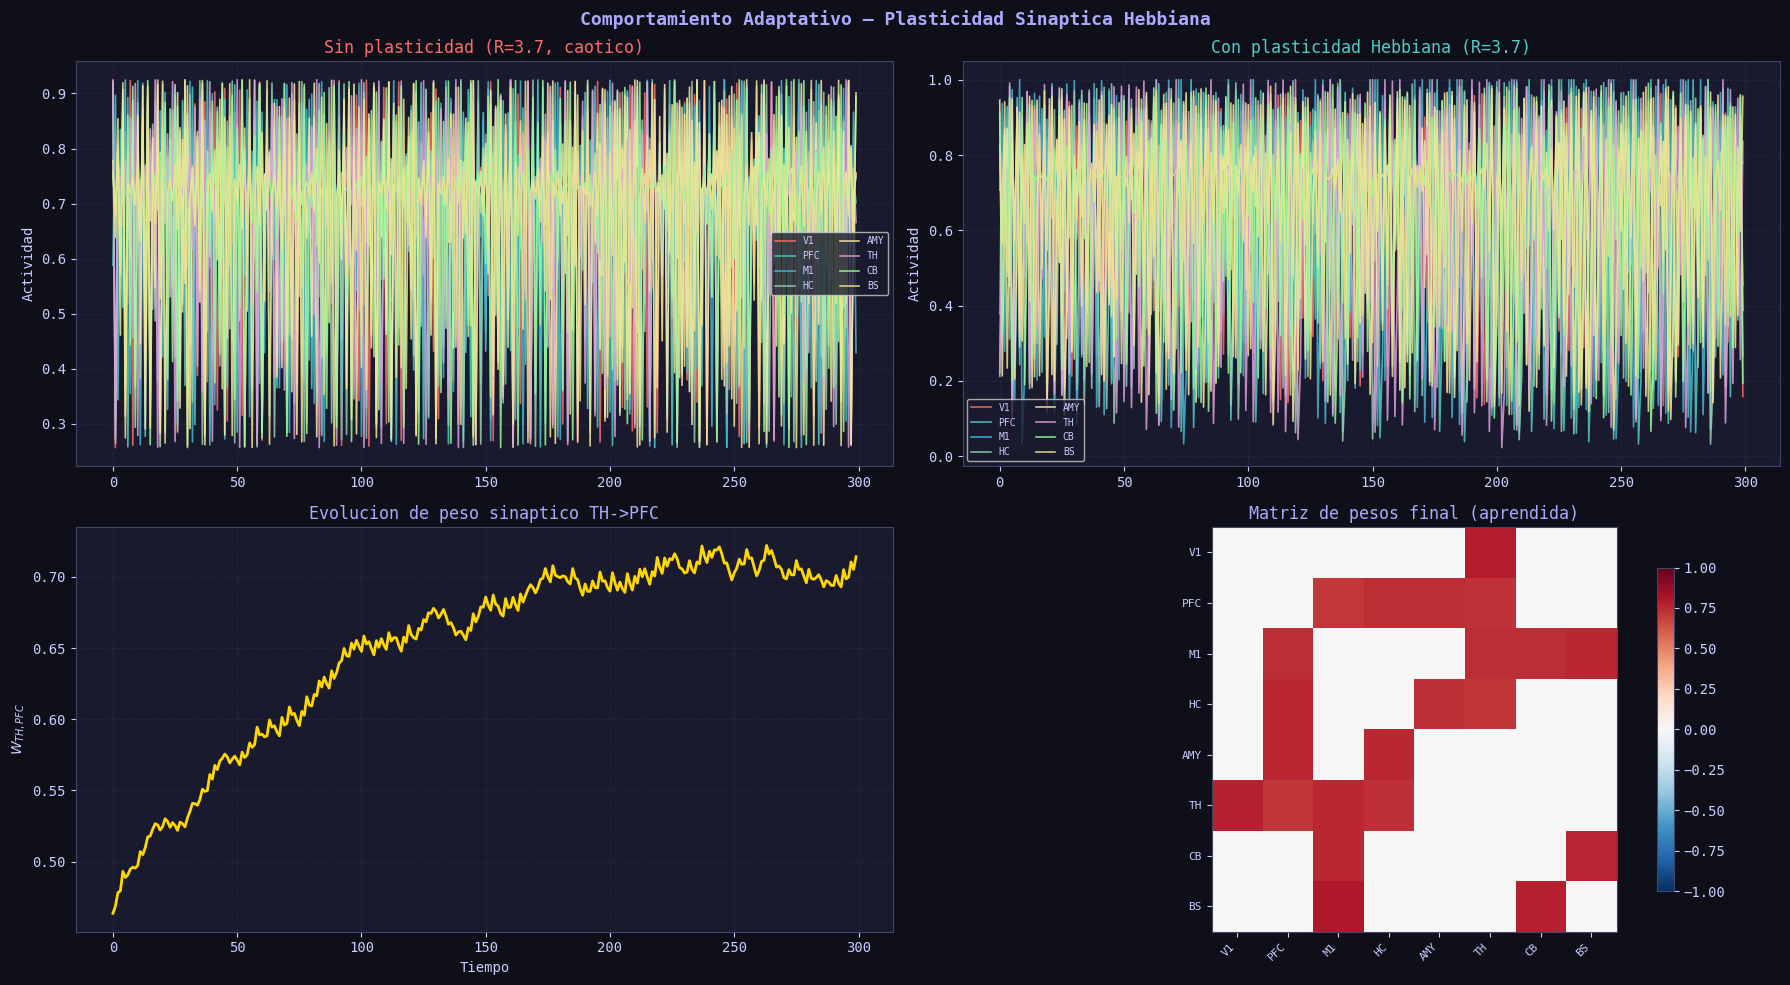

In [13]:
# ============================================================
# CELDA 12: Comportamiento Adaptativo — Plasticidad sinaptica
# ============================================================

def simular_con_plasticidad(A_bin, R_val, x0, T=300, T_trans=50, eps=0.05, eta=0.02, delta=0.01):
    N_nodos = len(x0)
    x = x0.copy()
    W_t = A_bin.copy() * 0.3  # Pesos iniciales debiles
    hist_x = []
    hist_W = []
    R_vec = np.full(N_nodos, R_val)
    for t in range(T + T_trans):
        x_new = R_vec * x * (1 - x) + eps * (W_t @ x)
        x_new = np.clip(x_new, 0, 1)
        # Actualizacion Hebbian
        dW = eta * np.outer(x_new, x) - delta * W_t
        W_t = W_t + dW * A_bin  # Solo actualizar conexiones existentes
        W_t = np.clip(W_t, -2, 2)
        x = x_new
        if t >= T_trans:
            hist_x.append(x.copy())
            hist_W.append(W_t.copy())
    return np.array(hist_x), np.array(hist_W)

np.random.seed(99)
x0 = np.random.uniform(0.1, 0.9, N)

hist_x_fijo,  _        = simular_red_logistica.__wrapped__(W_norm, np.full(N,3.7), x0) if False else \
    (lambda W, R, x: (simular_red_logistica(W, R, x, T=300), None))(W_norm, np.full(N,3.7), x0)

hist_x_fijo  = simular_red_logistica(W_norm*0, np.full(N,3.7), x0, T=300)
hist_x_plast, hist_W_plast = simular_con_plasticidad(A, 3.7, x0, T=300)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Comportamiento Adaptativo — Plasticidad Sinaptica Hebbiana', fontsize=13, color='#aaaaff', fontweight='bold')

# Sin plasticidad
for i, (reg, col) in enumerate(zip(REGIONES, COLORES)):
    axes[0,0].plot(hist_x_fijo[:, i], color=col, lw=1.2, label=reg, alpha=0.85)
axes[0,0].set_title('Sin plasticidad (R=3.7, caotico)', color='#ff6b6b')
axes[0,0].set_ylabel('Actividad'); axes[0,0].legend(fontsize=7, ncol=2); axes[0,0].grid()

# Con plasticidad
for i, (reg, col) in enumerate(zip(REGIONES, COLORES)):
    axes[0,1].plot(hist_x_plast[:, i], color=col, lw=1.2, label=reg, alpha=0.85)
axes[0,1].set_title('Con plasticidad Hebbiana (R=3.7)', color='#4ecdc4')
axes[0,1].set_ylabel('Actividad'); axes[0,1].legend(fontsize=7, ncol=2); axes[0,1].grid()

# Evolucion del peso TH->PFC
i_TH, i_PFC = REGIONES.index('TH'), REGIONES.index('PFC')
axes[1,0].plot(hist_W_plast[:, i_TH, i_PFC], color='#ffd700', lw=2)
axes[1,0].set_title('Evolucion de peso sinaptico TH->PFC', color='#aaaaff')
axes[1,0].set_xlabel('Tiempo'); axes[1,0].set_ylabel('$W_{TH,PFC}$'); axes[1,0].grid()

# Matriz de pesos final
im = axes[1,1].imshow(hist_W_plast[-1], cmap='RdBu_r', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(N)); axes[1,1].set_yticks(range(N))
axes[1,1].set_xticklabels(REGIONES, rotation=45, ha='right', fontsize=8)
axes[1,1].set_yticklabels(REGIONES, fontsize=8)
axes[1,1].set_title('Matriz de pesos final (aprendida)', color='#aaaaff')
plt.colorbar(im, ax=axes[1,1], shrink=0.8)

plt.tight_layout()
plt.savefig('fig12_plasticidad.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Redes Ecológicas — Analogía con Redes Cerebrales

Las **redes ecológicas** clasifican las interacciones entre especies. Esta misma taxonomía aplica directamente a circuitos cerebrales:

| Tipo en Ecología | Signos | Tipo en Cerebro | Ejemplo |
|:----------------:|:------:|:---------------:|:-------:|
| Depredación | +/− | Excitación-Inhibición | Glutamato-GABA |
| Mutualismo | +/+ | Sincronización | Oscilaciones gamma |
| Competencia | −/− | Inhibición lateral | Procesamiento visual |
| Comensalismo | +/0 | Facilitación | Priming atencional |
| Amensalismo | 0/− | Supresión unilateral | Control top-down |

### El diagrama de bifurcación: herramienta universal
Igual que en ecología, el **diagrama de bifurcación** revela cómo el parámetro de excitabilidad $R$ controla la transición:

$$\text{Reposo} \xrightarrow{R\uparrow} \text{Ritmos} \xrightarrow{R\uparrow} \text{Caos (epilepsia)}$$

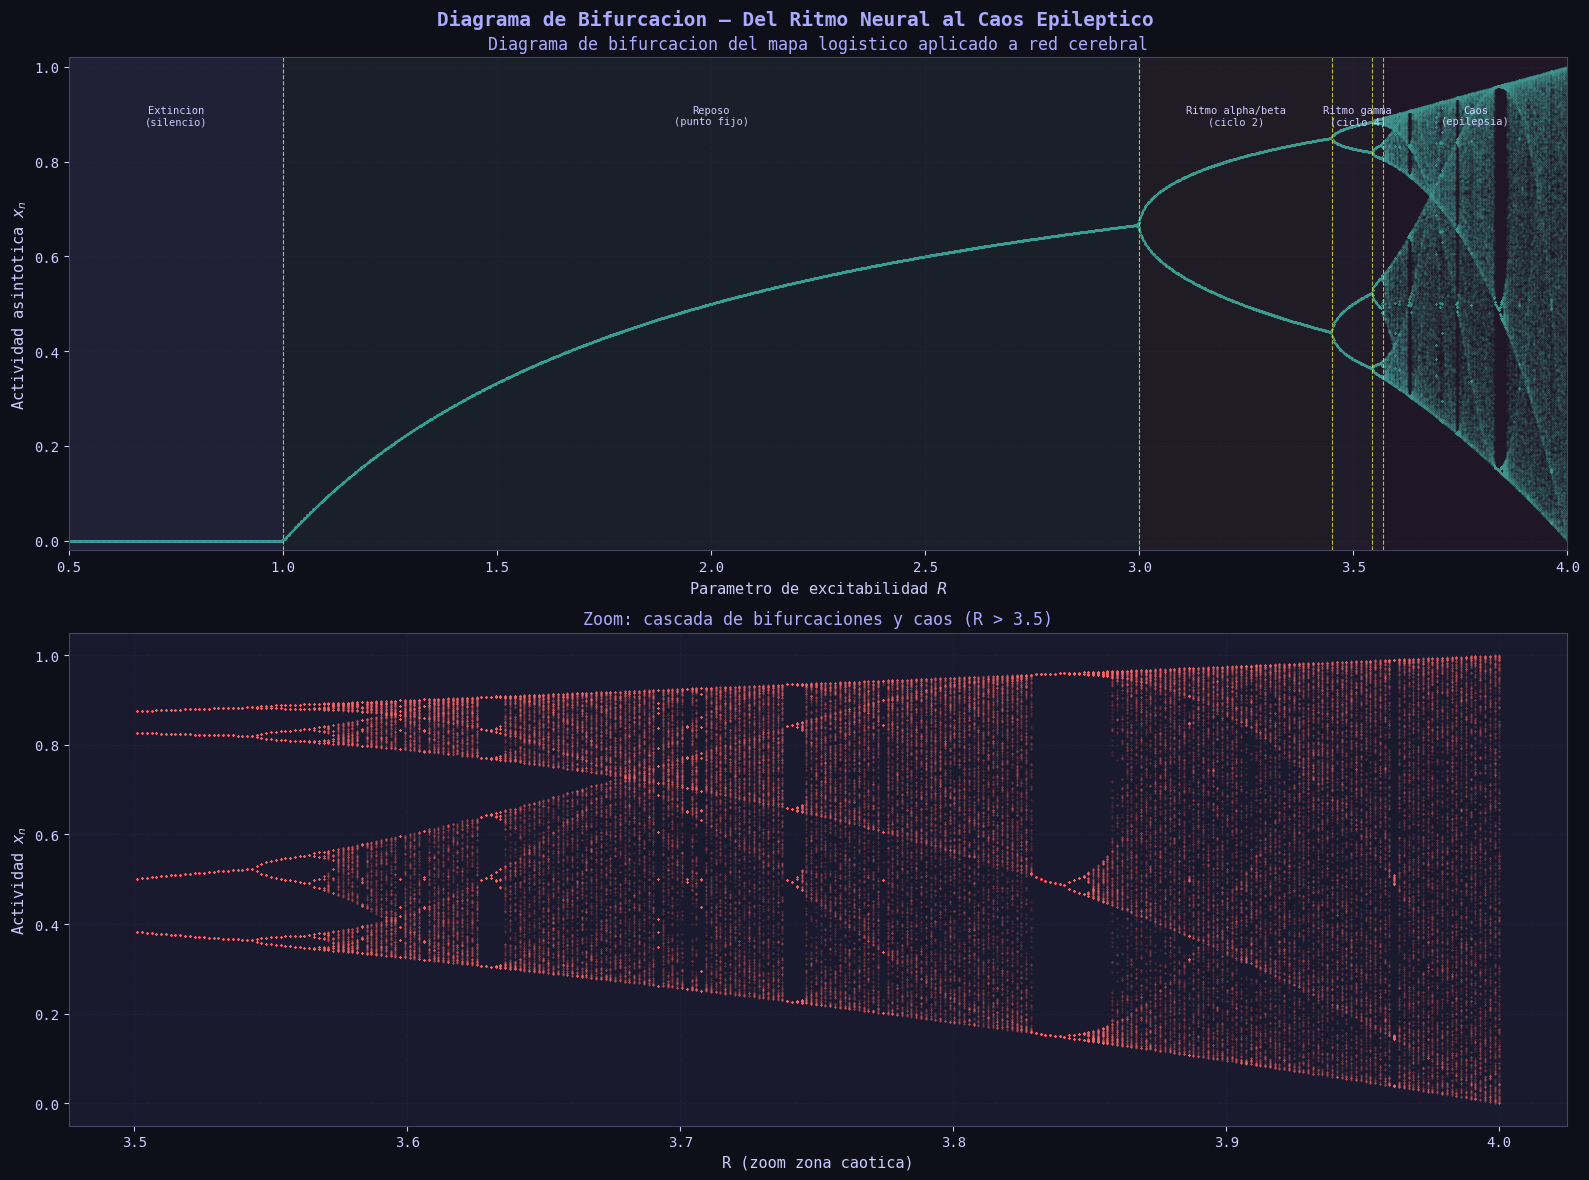

In [14]:
# ============================================================
# CELDA 13: Diagrama de Bifurcacion — reproduccion exacta del video
# ============================================================

R_range = np.linspace(0.5, 4.0, 2000)
n_trans = 500   # iteraciones a descartar
n_plot  = 300   # iteraciones a graficar
x_bif   = 0.1

R_pts, X_pts = [], []
for R in R_range:
    x = x_bif
    for _ in range(n_trans):
        x = R * x * (1 - x)
    for _ in range(n_plot):
        x = R * x * (1 - x)
        R_pts.append(R)
        X_pts.append(x)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Diagrama de Bifurcacion — Del Ritmo Neural al Caos Epileptico', fontsize=14, color='#aaaaff', fontweight='bold')

# --- Diagrama completo ---
ax = axes[0]
ax.scatter(R_pts, X_pts, s=0.05, c='#4ecdc4', alpha=0.3)

# Zonas anotadas
zonas = [
    (0.5,  1.0,  '#333355', 'Extincion\n(silencio)'),
    (1.0,  3.0,  '#1a3322', 'Reposo\n(punto fijo)'),
    (3.0,  3.45, '#332211', 'Ritmo alpha/beta\n(ciclo 2)'),
    (3.45, 3.57, '#332222', 'Ritmo gamma\n(ciclo 4)'),
    (3.57, 4.0,  '#331111', 'Caos\n(epilepsia)'),
]
for (r1, r2, col, label) in zonas:
    ax.axvspan(r1, r2, alpha=0.25, color=col)
    ax.text((r1+r2)/2, 0.92, label, ha='center', va='top', fontsize=7.5,
            color='#ccccff', wrap=True)

# Lineas de bifurcacion
for r_bif, label in [(1.0,''), (3.0,''), (3.449,''), (3.544,''), (3.5695,'')]:
    ax.axvline(r_bif, color='#ffff44', linewidth=0.8, linestyle='--', alpha=0.7)

ax.set_xlabel('Parametro de excitabilidad $R$', fontsize=11)
ax.set_ylabel('Actividad asintotica $x_n$', fontsize=11)
ax.set_title('Diagrama de bifurcacion del mapa logistico aplicado a red cerebral', color='#aaaaff')
ax.set_xlim(0.5, 4.0); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.2)

# --- Zoom en la zona caotica ---
ax2 = axes[1]
mask = np.array(R_pts) > 3.5
ax2.scatter(np.array(R_pts)[mask], np.array(X_pts)[mask], s=0.08, c='#ff6b6b', alpha=0.4)
ax2.set_xlabel('R (zoom zona caotica)', fontsize=11)
ax2.set_ylabel('Actividad $x_n$', fontsize=11)
ax2.set_title('Zoom: cascada de bifurcaciones y caos (R > 3.5)', color='#aaaaff')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('fig13_bifurcacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Características de las Redes

Las redes complejas tienen propiedades estructurales que determinan su dinámica. Las más importantes en redes cerebrales son:

| Propiedad | Definición | Interpretación cerebral |
|-----------|------------|------------------------|
| **Grado medio** $\langle k \rangle$ | Promedio de conexiones por nodo | Conectividad promedio de regiones |
| **Coeficiente de clustering** $C_c$ | Fracción de triángulos cerrados | Modularidad local (grupos funcionales) |
| **Centralidad de intermediación** | Cuántos caminos pasan por un nodo | Regiones "hub" de comunicación |
| **Longitud de camino medio** $\langle d \rangle$ | Distancia promedio entre nodos | Eficiencia de comunicación |
| **Small-world index** | $\langle d \rangle$ pequeño + $C_c$ alto | El cerebro real es small-world |
| **Distribución de grados** | $P(k)$ | Scale-free o exponencial |

### El cerebro como red small-world
El cerebro real tiene: $\langle d \rangle$ bajo (comunicación eficiente) y $C_c$ alto (módulos especializados). Esta combinación es óptima para el procesamiento de información.

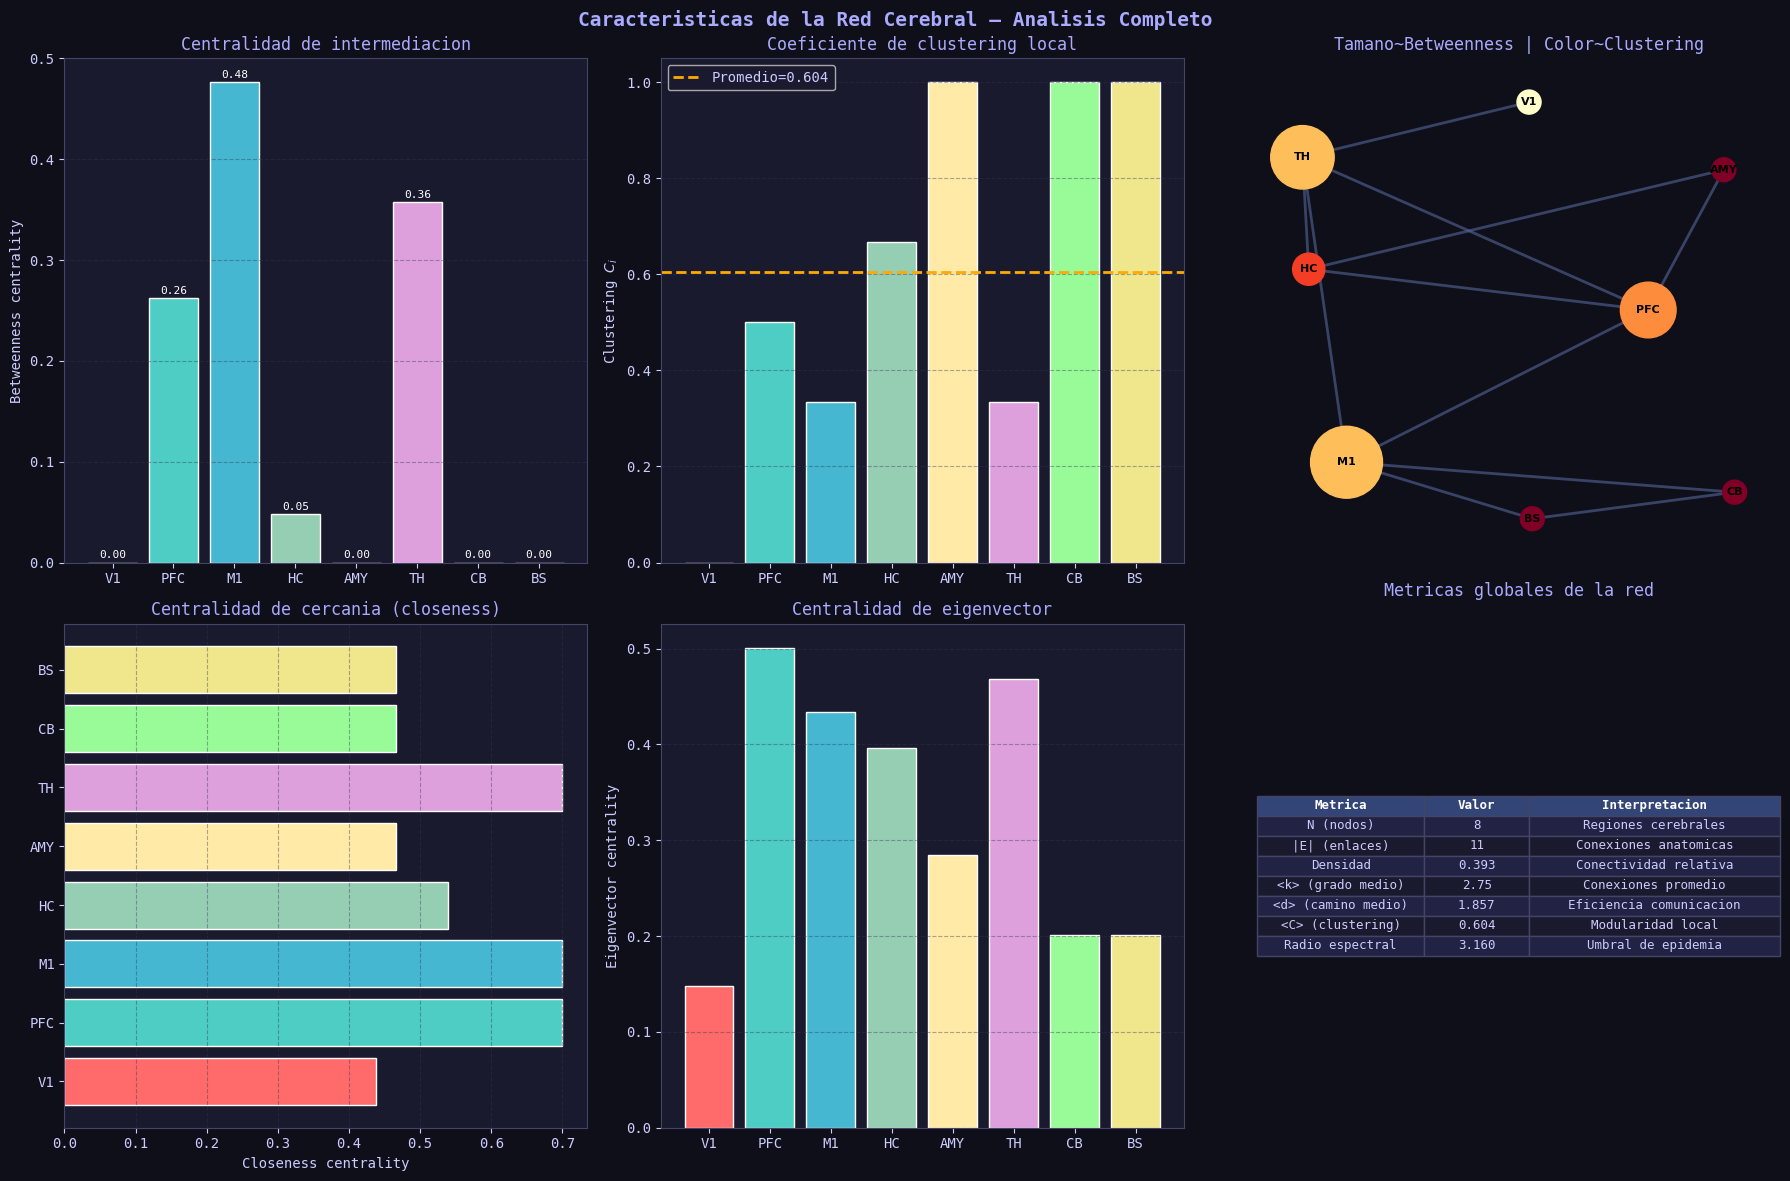

Small-World Index sigma = 1.3462
  (sigma > 1 indica propiedad small-world)

Hub principal: M1 (Corteza Motora)
Region mas central: PFC


In [15]:
# ============================================================
# CELDA 14: Caracteristicas de la Red — Analisis completo
# ============================================================

# Metricas de la red cerebral
betweenness   = nx.betweenness_centrality(G)
closeness     = nx.closeness_centrality(G)
clustering    = nx.clustering(G)
eigenvector   = nx.eigenvector_centrality(G, max_iter=1000)
avg_path      = nx.average_shortest_path_length(G)
avg_cluster   = nx.average_clustering(G)
density       = nx.density(G)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Caracteristicas de la Red Cerebral — Analisis Completo', fontsize=14, color='#aaaaff', fontweight='bold')

# 1. Centralidad de intermediacion
ax = axes[0,0]
bet_vals = [betweenness[r] for r in REGIONES]
bars = ax.bar(REGIONES, bet_vals, color=COLORES, edgecolor='white')
ax.set_title('Centralidad de intermediacion', color='#aaaaff')
ax.set_ylabel('Betweenness centrality')
ax.grid(axis='y')
for bar, val in zip(bars, bet_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002, f'{val:.2f}',
            ha='center', va='bottom', fontsize=8, color='white')

# 2. Clustering local
ax2 = axes[0,1]
clust_vals = [clustering[r] for r in REGIONES]
bars2 = ax2.bar(REGIONES, clust_vals, color=COLORES, edgecolor='white')
ax2.axhline(avg_cluster, color='#ffaa00', linestyle='--', linewidth=2,
            label=f'Promedio={avg_cluster:.3f}')
ax2.set_title('Coeficiente de clustering local', color='#aaaaff')
ax2.set_ylabel('Clustering $C_i$')
ax2.legend(); ax2.grid(axis='y')

# 3. Red con metricas visualizadas
ax3 = axes[0,2]
ax3.set_facecolor('#1a1a2e')
bet_sizes = [5000*betweenness[n]+300 for n in REGIONES]
clust_colors = [clustering[n] for n in REGIONES]
nodes = nx.draw_networkx_nodes(G, pos, ax=ax3, node_color=clust_colors,
    node_size=bet_sizes, cmap='YlOrRd', vmin=0, vmax=1)
nx.draw_networkx_edges(G, pos, ax=ax3, edge_color='#556699', width=2, alpha=0.6)
nx.draw_networkx_labels(G, pos, ax=ax3, font_color='black', font_size=8, font_weight='bold')
ax3.set_title('Tamano~Betweenness | Color~Clustering', color='#aaaaff')
ax3.axis('off')

# 4. Centralidad de cercania
ax4 = axes[1,0]
clos_vals = [closeness[r] for r in REGIONES]
bars4 = ax4.barh(REGIONES, clos_vals, color=COLORES, edgecolor='white')
ax4.set_title('Centralidad de cercania (closeness)', color='#aaaaff')
ax4.set_xlabel('Closeness centrality')
ax4.grid(axis='x')

# 5. Centralidad de vector propio
ax5 = axes[1,1]
eig_vals = [eigenvector[r] for r in REGIONES]
ax5.bar(REGIONES, eig_vals, color=COLORES, edgecolor='white')
ax5.set_title('Centralidad de eigenvector', color='#aaaaff')
ax5.set_ylabel('Eigenvector centrality')
ax5.grid(axis='y')

# 6. Tabla resumen de metricas globales
ax6 = axes[1,2]
ax6.axis('off')
ax6.set_facecolor('#1a1a2e')
metricas = [
    ['Metrica', 'Valor', 'Interpretacion'],
    ['N (nodos)', str(N), 'Regiones cerebrales'],
    ['|E| (enlaces)', str(G.number_of_edges()), 'Conexiones anatomicas'],
    ['Densidad', f'{density:.3f}', 'Conectividad relativa'],
    ['<k> (grado medio)', f'{np.mean(grado_vals):.2f}', 'Conexiones promedio'],
    ['<d> (camino medio)', f'{avg_path:.3f}', 'Eficiencia comunicacion'],
    ['<C> (clustering)', f'{avg_cluster:.3f}', 'Modularidad local'],
    ['Radio espectral', f'{eigenvalores.max():.3f}', 'Umbral de epidemia'],
]
table = ax6.table(cellText=metricas[1:], colLabels=metricas[0],
                  cellLoc='center', loc='center',
                  colWidths=[0.32, 0.2, 0.48])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#334477'); cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a2e' if row%2==0 else '#222244')
        cell.set_text_props(color='#ccccff')
    cell.set_edgecolor('#444466')
ax6.set_title('Metricas globales de la red', color='#aaaaff', pad=20)

plt.tight_layout()
plt.savefig('fig14_caracteristicas_red.png', dpi=150, bbox_inches='tight')
plt.show()

# Indice Small-World (comparacion con red aleatoria equivalente)
G_rand = nx.erdos_renyi_graph(N, density, seed=42)
if nx.is_connected(G_rand):
    d_rand = nx.average_shortest_path_length(G_rand)
    c_rand = nx.average_clustering(G_rand)
    sigma_sw = (avg_cluster/c_rand) / (avg_path/d_rand)
    print(f'Small-World Index sigma = {sigma_sw:.4f}')
    print(f'  (sigma > 1 indica propiedad small-world)')
print(f'\nHub principal: {max(betweenness, key=betweenness.get)} ({NOMBRES[REGIONES.index(max(betweenness, key=betweenness.get))]})')
print(f'Region mas central: {max(closeness, key=closeness.get)}')

---
## Reflexión Crítica y Conclusiones

### Lo que el modelo captura correctamente
1. La **topología de la red** (matriz de adyacencia, pesos, dirección) refleja la conectividad anatómica real del cerebro
2. La **transición al caos** con el mapa logístico es matemáticamente análoga a la transición a actividad epiléptica
3. El **modelo E-I tipo Lotka-Volterra** reproduce los ciclos de activación que se observan en EEG
4. Las **métricas de red** (clustering, camino medio) corresponden a propiedades medibles con neuroimagen

### Limitaciones del modelo
1. **Homogeneidad espacial**: se asume que cada región es homogénea, ignorando la estructura interna de millones de neuronas
2. **Escala temporal**: el mapa logístico discreto no captura las diferentes escalas de tiempo neuronal (ms para disparos, s para ritmos, h para aprendizaje)
3. **Ausencia de geometría**: el cerebro existe en 3D; la distancia física entre regiones afecta la latencia de transmisión
4. **Sin ruido**: los sistemas neuronales reales son intrínsecamente estocásticos

### Extensiones posibles
- Usar el **conectoma humano real** (datos de Human Connectome Project)
- Incorporar **redes de mundo pequeño** (*small-world*) artificiales
- Modelar **perturbaciones**: lesiones cerebrales como eliminación de nodos
- Estudiar **sincronización**: cuándo dos regiones colapsan en fase (relevante para anestesia y estados de conciencia)

---
*El modelamiento matemático unifica la biología, la física y la neurociencia bajo el lenguaje común de los sistemas dinámicos. El caos cerebral no es disfunción: es la señal de que el sistema opera en el borde entre orden y complejidad.*